# Chatbots & Recommendation Engines - Group 6
## Food.com Recipe Recommender System

**Dataset**: Food.com Recipes and User Interactions  
**Source**: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

**Team Members**: Adriana Castañon, María José Colmenarez, Joud Taher, Beatriz Martín

<img src="https://drive.google.com/uc?export=view&id=1wIE22tjli0_rg27P_H1aLwWCt9XgQp23" alt="IE" width="150"/>

---

**Business context**: We got hired by Food.com, a company which currently relies on a randomized recommendation strategy for recipies from their 200k item catalog. Our purpose is to boost their user experience by using their 18 years of user interaction data in order to provide personalized recommendations. To do this, we design, implement, and evaluate a full recommendation system, boosting customer satisfaction and engagement with the service, and estimate the value it would add to the organization.

## 0. Setup & Environment

All random seeds are fixed for full reproducibility.

In [3]:
%%capture

# If running on Google Colab, uncomment the following:
# 1. Change Python version in Colab [Runtime → Change runtime type → Version to "2025.07"]
# !pip install surprise recmetrics

# If running locally:
# pip install scikit-surprise recmetrics pandas numpy matplotlib seaborn plotly tqdm scikit-learn kaggle

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn.metrics as metrics
from tqdm import tqdm
import random
import math
import warnings
import ast, os
import re

from scipy import sparse
from surprise import Reader, Dataset, SVD, AlgoBase, accuracy, Prediction
from surprise.model_selection import train_test_split, cross_validate, KFold
import recmetrics

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.preprocessing import StandardScaler, normalize
import sklearn.metrics as metrics

import spacy
from sentence_transformers import SentenceTransformer

# ── Reproducibility ──────────────────────────────────────────
my_seed = 42
random.seed(my_seed)
np.random.seed(my_seed)

# ── Plotting style ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
MAIN_COLOR      = "#82B2C0"
SECONDARY_COLOR = "#E91E63"
ACCENT_COLOR    = "#F6C7B3"
PALETTE         = "Blues"
COLOR_MAP       = ["#82B2C0", "#E91E63", "#F6C7B3", "#F0E2C3", "#C3DEDD", "#E79572"]
warnings.filterwarnings('ignore')

print("Environment ready ✓")

Environment ready ✓


### 0.1 Download and load the dataset

We use the **Food.com Recipes and User Interactions** dataset, which contains 230K+ recipes and 1.1M+ user interactions accross 18 years (2000–2018). 

It includes:
- **Explicit ratings** from 0 to 5 with timestamps, good for CF and evaluation
- **Rich item metadata** with tags, nutrition, description, ingredients, steps etc, good for content-based
- **Temporal data** including dates on every interaction, good for context-aware

This is an ideal dataset as it allows us to explore every approach seen in class.

In [5]:
# ── Kaggle download ──────────────────────────────────────────
# Option A: Local Kaggle setup — place your kaggle.json in the same folder as this notebook
import os
os.environ["KAGGLE_CONFIG_DIR"] = os.path.dirname(os.path.abspath("__file__"))

import kaggle
kaggle.api.authenticate()

dataset_path = 'shuyangli94/food-com-recipes-and-user-interactions'
kaggle.api.dataset_download_files(dataset_path, path=dataset_path, unzip=True)

print("Downloaded files:", os.listdir(dataset_path))

Dataset URL: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions
Downloaded files: ['ingr_map.pkl', 'interactions_test.csv', 'interactions_train.csv', 'interactions_validation.csv', 'PP_recipes.csv', 'PP_users.csv', 'RAW_interactions.csv', 'RAW_recipes.csv']


In [6]:
# ── Load the two main files ───────────────────────────────────
recipes_df = pd.read_csv(f'{dataset_path}/RAW_recipes.csv')
interactions_df = pd.read_csv(f'{dataset_path}/RAW_interactions.csv')

print(f"Recipes shape: {recipes_df.shape}")
print(f"Interactions shape: {interactions_df.shape}")

Recipes shape: (231637, 12)
Interactions shape: (1132367, 5)


In [7]:
recipes_df.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [8]:
interactions_df.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


## 1. Data Exploration & Preprocessing

The core step efore building any recommender is understanding the data we are dealing with. 
* We will follow the standard ML pipeline: explore → clean → preprocess → split.

### 1.1 Basic statistics

In [9]:
n_ratings = interactions_df.shape[0]
n_users = interactions_df['user_id'].nunique()
n_items = interactions_df['recipe_id'].nunique()
sparsity = 1 - n_ratings / (n_users * n_items)

print(f"Total interactions:  {n_ratings:,}")
print(f"Unique users:        {n_users:,}")
print(f"Unique recipes:      {n_items:,}")
print(f"Sparsity:            {sparsity:.6%}")
print(f"Avg ratings/user:    {n_ratings / n_users:.1f}")
print(f"Avg ratings/item:    {n_ratings / n_items:.1f}")

Total interactions:  1,132,367
Unique users:        226,570
Unique recipes:      231,637
Sparsity:            99.997842%
Avg ratings/user:    5.0
Avg ratings/item:    4.9


As in most recommender systems environments, the dataset is very sparse (99.998%), meaning most user-item pairs have no observed interaction, we aim to predict which unobserved pairs would likely produce a positive interaction.

### 1.2 Rating distribution

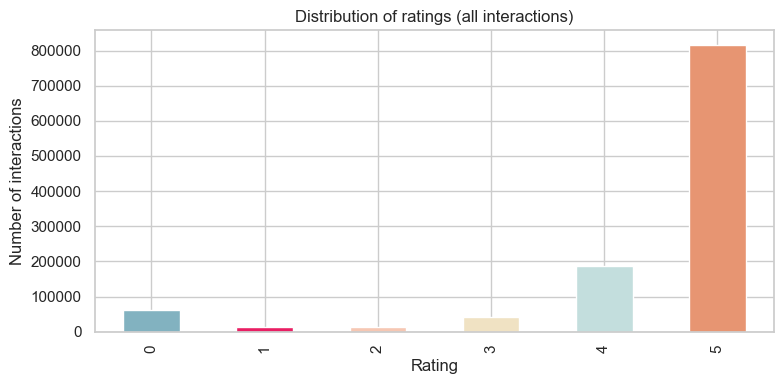

In [10]:
plt.figure(figsize=(8, 4))
interactions_df.groupby('rating').size().plot.bar(color=COLOR_MAP)
plt.ylabel('Number of interactions')
plt.xlabel('Rating')
plt.title('Distribution of ratings (all interactions)')
plt.tight_layout()
plt.show()

On Food.com platform, users can rate recipes on a 1–5 star scale, however, we can see ratings of 0 exist in this dataset. This indicates the user left a review but didn't give a rating, so we will treat this as missing data, which has been the standard approach through all published analyses of this dataset.

We will filter the 0 rating out and work with explicit ratings (1–5) for training our recommenders with the Surprise library. For the hybrid approach, the 60K interactions with 0 rating could potentially be seen as implicit positive feedback (as the user engaged enough to write a review).

In [11]:
# ── Separate explicit vs missing feedback ────────────────────
explicit_df = interactions_df[interactions_df['rating'] > 0].copy()
implicit_df = interactions_df[interactions_df['rating'] == 0].copy()

print(f"Explicit feedback (rating 1-5): {len(explicit_df):,} interactions "
      f"({len(explicit_df)/len(interactions_df)*100:.1f}%)")
print(f"Missing feedback (rating 0):   {len(implicit_df):,} interactions "
      f"({len(implicit_df)/len(interactions_df)*100:.1f}%)")
print(f"\nExplicit - unique users: {explicit_df['user_id'].nunique():,}")
print(f"Explicit - unique items: {explicit_df['recipe_id'].nunique():,}")

Explicit feedback (rating 1-5): 1,071,520 interactions (94.6%)
Missing feedback (rating 0):   60,847 interactions (5.4%)

Explicit - unique users: 196,098
Explicit - unique items: 226,590


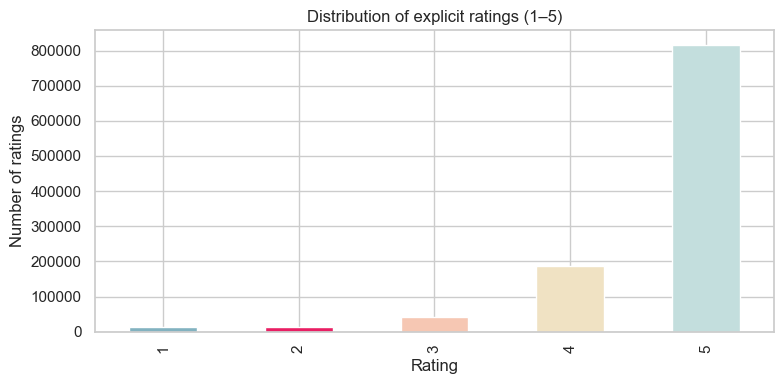

Mean rating: 4.66
Std rating:  0.7231


In [12]:
# Explicit rating distribution
plt.figure(figsize=(8, 4))
explicit_df.groupby('rating').size().plot.bar(color=COLOR_MAP)
plt.ylabel('Number of ratings')
plt.xlabel('Rating')
plt.title('Distribution of explicit ratings (1–5)')
plt.tight_layout()
plt.show()

print(f"Mean rating: {explicit_df['rating'].mean():.2f}")
print(f"Std rating:  {explicit_df['rating'].std():.4f}")

Most users tend to give positive ratings (heavy left-skewed plot), specially between 4-5, indicating users tend to rate recipes they enjoyed. The Popular recommender will hence predict high ratings for most recipies, so NDCG will be an important metric to compare between recommenders rather than just RMSE.

### 1.3 Missing values & duplicates

In [13]:
print("Missing values in interactions:")
print(interactions_df.isna().sum())
print(f"\nDuplicate rows in interactions: {interactions_df.duplicated().sum()}")
print(f"\nMissing values in recipes:")
print(recipes_df.isna().sum())

Missing values in interactions:
user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64

Duplicate rows in interactions: 0

Missing values in recipes:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64


### 1.4 User and item interaction distributions

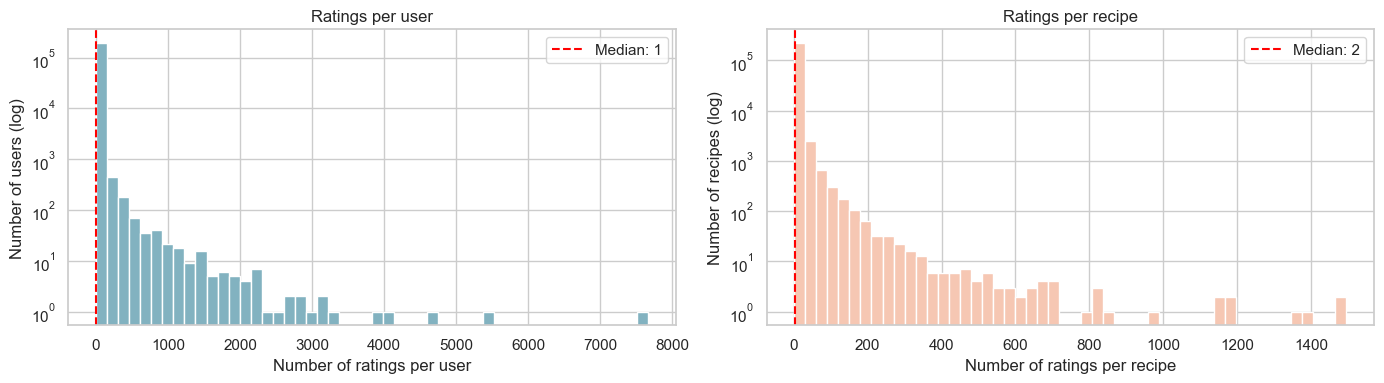

Users  — median: 1, mean: 5.5, max: 7665
Items  — median: 2, mean: 4.7, max: 1496


In [14]:
user_counts = explicit_df.groupby('user_id').size()
item_counts = explicit_df.groupby('recipe_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_counts.values, bins=50, color=MAIN_COLOR, log=True)
axes[0].set_xlabel('Number of ratings per user')
axes[0].set_ylabel('Number of users (log)')
axes[0].set_title('Ratings per user')
axes[0].axvline(user_counts.median(), color='red', linestyle='--', label=f'Median: {user_counts.median():.0f}')
axes[0].legend()

axes[1].hist(item_counts.values, bins=50, color=ACCENT_COLOR, log=True)
axes[1].set_xlabel('Number of ratings per recipe')
axes[1].set_ylabel('Number of recipes (log)')
axes[1].set_title('Ratings per recipe')
axes[1].axvline(item_counts.median(), color='red', linestyle='--', label=f'Median: {item_counts.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Users  — median: {user_counts.median():.0f}, mean: {user_counts.mean():.1f}, "
      f"max: {user_counts.max()}")
print(f"Items  — median: {item_counts.median():.0f}, mean: {item_counts.mean():.1f}, "
      f"max: {item_counts.max()}")

**The long-tail phenomenon** is clearly illustrated, both distributions are heavily right-skewed, most users give few ratings, and most recipes have very few ratings.

The median user has only 1 rating and the median item 2 ratings, confirming extreme sparsity. The user that gave most ratings gave 7,665 and the most rated item has 1,496, showing the heavy-tail. It will be important to filer users and items with very few interactions, as they don't provide enough signal for collaborative filtering.

### 1.5 Long-tail phenomenon

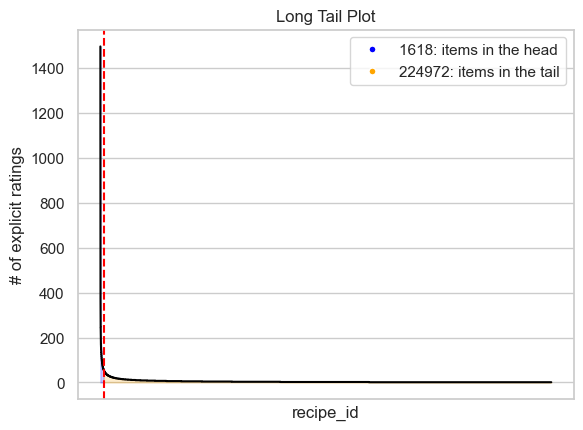

In [15]:
# recmetrics creates its own figure — do NOT wrap with plt.figure()
recmetrics.long_tail_plot(
    df=explicit_df,
    item_id_column="recipe_id",
    interaction_type="explicit ratings",
    percentage=0.2,
    x_labels=False
)

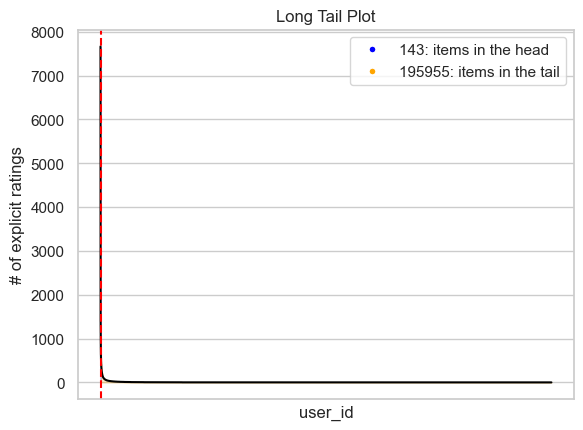

In [16]:
recmetrics.long_tail_plot(
    df=explicit_df,
    item_id_column="user_id",
    interaction_type="explicit ratings",
    percentage=0.2,
    x_labels=False
)

The Popular recommender will be great at recommending head items but will have poor coverage of the items in the tail, while data-driven recommenders like CF and CB will likely help surface long-tail recipes that match user preferences.

In [17]:
# What % of items account for 80% of ratings?
item_sorted = item_counts.sort_values(ascending=False)
cumsum = item_sorted.cumsum()
pct_items_for_80 = (cumsum <= cumsum.iloc[-1] * 0.8).sum() / len(item_sorted) * 100
print(f"{pct_items_for_80:.1f}% of recipes account for 80% of all explicit ratings")

35.0% of recipes account for 80% of all explicit ratings


### 1.6 Average rating distributions

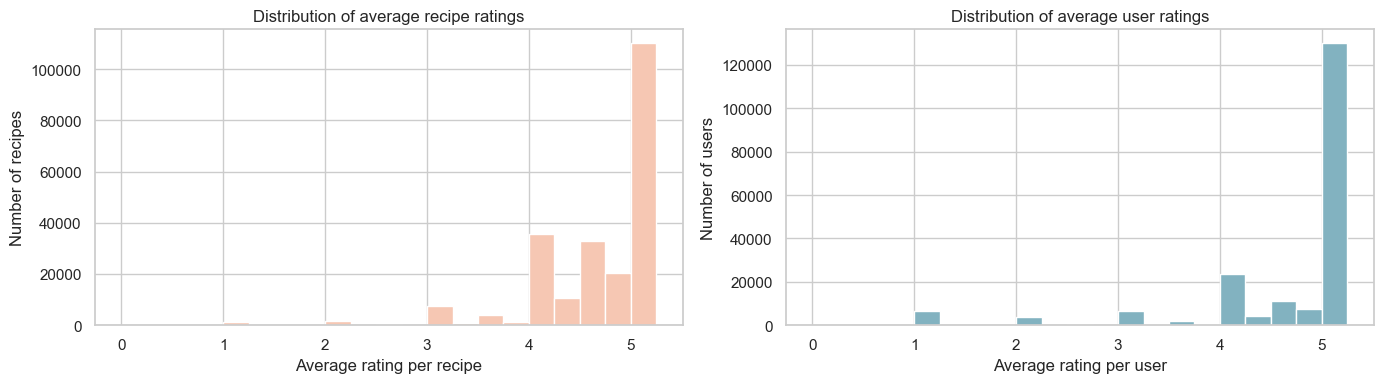

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

explicit_df.groupby('user_id')['rating'].mean().hist(
    bins=np.arange(0, 5.5, 0.25), ax=axes[1], color=MAIN_COLOR)
axes[1].set_xlabel('Average rating per user')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Distribution of average user ratings')

explicit_df.groupby('recipe_id')['rating'].mean().hist(
    bins=np.arange(0, 5.5, 0.25), ax=axes[0], color=ACCENT_COLOR)
axes[0].set_xlabel('Average rating per recipe')
axes[0].set_ylabel('Number of recipes')
axes[0].set_title('Distribution of average recipe ratings')

plt.tight_layout()
plt.show()

### 1.7 Item metadata exploration

#### Numerical columns

In [19]:
# Parse the nutrition column: [calories, total_fat_PDV, sugar_PDV, sodium_PDV, protein_PDV, sat_fat_PDV, carbs_PDV]
import ast

recipes_df['nutrition_parsed'] = recipes_df['nutrition'].apply(ast.literal_eval)
nutrition_cols = ['calories', 'total_fat_PDV', 'sugar_PDV', 'sodium_PDV',
                  'protein_PDV', 'sat_fat_PDV', 'carbs_PDV']
recipes_df[nutrition_cols] = pd.DataFrame(
    recipes_df['nutrition_parsed'].tolist(), index=recipes_df.index
)

print("Numerical columns available for content-based recommenders:")
num_cols = ['minutes', 'n_steps', 'n_ingredients'] + nutrition_cols
recipes_df[num_cols].describe().round(1)

Numerical columns available for content-based recommenders:


,minutes,n_steps,n_ingredients,calories,total_fat_PDV,sugar_PDV,sodium_PDV,protein_PDV,sat_fat_PDV,carbs_PDV
count,2.316370e+05,231637.0,231637.0,231637.0,231637.0,231637.0,231637.0,231637.0,231637.0,231637.0
mean,9.398500e+03,9.8,9.1,473.9,36.1,84.3,30.1,34.7,45.6,15.6
std,4.461963e+06,6.0,3.7,1189.7,77.8,800.1,132.0,58.5,98.2,81.8
min,0.000000e+00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000e+01,6.0,6.0,174.4,8.0,9.0,5.0,7.0,7.0,4.0
50%,4.000000e+01,9.0,9.0,313.4,20.0,25.0,14.0,18.0,23.0,9.0
75%,6.500000e+01,12.0,11.0,519.7,41.0,68.0,33.0,51.0,52.0,16.0
max,2.147484e+09,145.0,43.0,434360.2,17183.0,362729.0,29338.0,6552.0,10395.0,36098.0


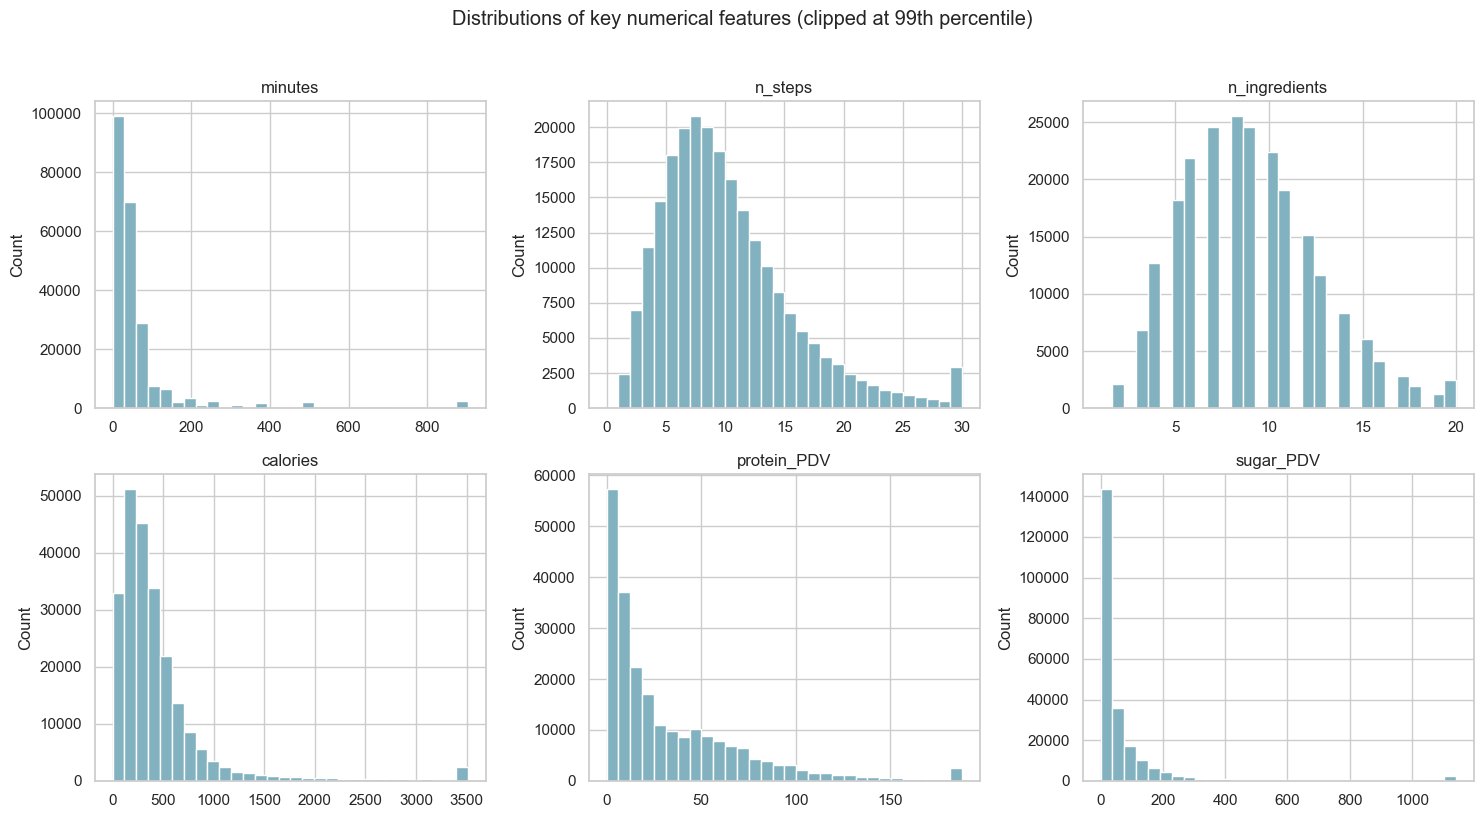

In [20]:
# Distribution of key numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ['minutes', 'n_steps', 'n_ingredients',
                                      'calories', 'protein_PDV', 'sugar_PDV']):
    # Clip outliers for visualization
    data = recipes_df[col].clip(upper=recipes_df[col].quantile(0.99))
    ax.hist(data.dropna(), bins=30, color=MAIN_COLOR)
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle('Distributions of key numerical features (clipped at 99th percentile)', y=1.02)
plt.tight_layout()
plt.show()

Several numerical features (like calories, protein and sugar) show concentration at zero, which likely represent missing values rather than true zeros. The minutes column also contains extreme outliers (recipes claiming hundreds of thousands of minutes). This will be handled during content-based preprocessing either by filtering outliers, replacing zeros with NaN, or clipping to reasonable ranges before normalization.

#### Categorical columns (tags)

Tags per recipe — mean: 17.9, median: 17, max: 73

Total unique tags: 552


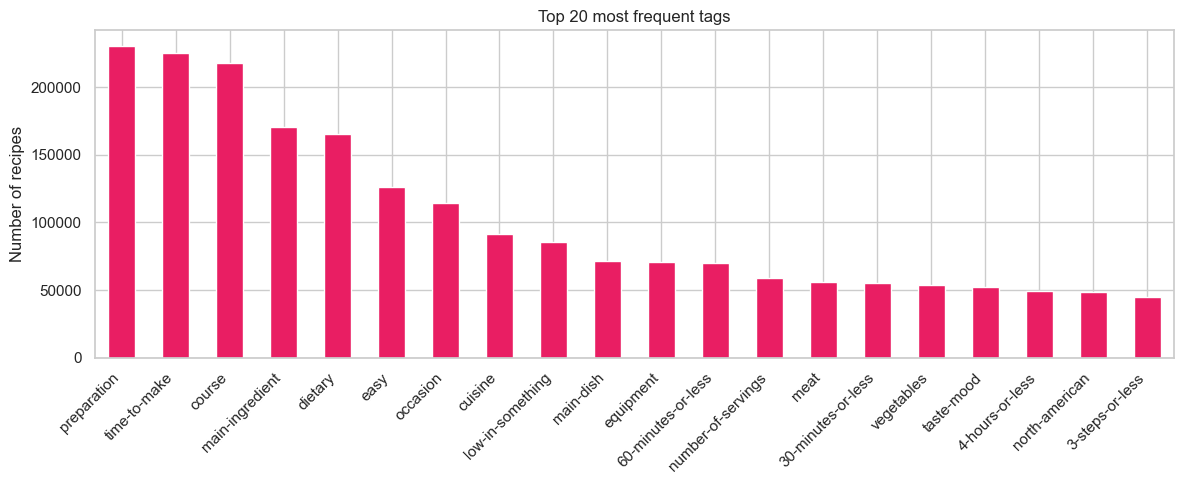

In [21]:
# Parse tags from string to list
recipes_df['tags_parsed'] = recipes_df['tags'].apply(ast.literal_eval)

# How many tags per recipe?
tag_counts = recipes_df['tags_parsed'].apply(len)
print(f"Tags per recipe — mean: {tag_counts.mean():.1f}, median: {tag_counts.median():.0f}, "
      f"max: {tag_counts.max()}")

# Explode and count
tags_exploded = recipes_df[['id', 'tags_parsed']].explode('tags_parsed')
tags_exploded.columns = ['recipe_id', 'tag']

print(f"\nTotal unique tags: {tags_exploded['tag'].nunique()}")

# Top 20 tags
plt.figure(figsize=(12, 5))
tags_exploded['tag'].value_counts().head(20).plot.bar(color=SECONDARY_COLOR)
plt.title('Top 20 most frequent tags')
plt.ylabel('Number of recipes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In this dataset, tags are used as the **category system** for recipes (`'dietary'`, `'desserts'`, `'vegetarian'`, `'healthy'` etc). These will be one-hot encoded and used for content-based similarity, diversity metrics, and potentially in context analysis.

#### Text columns

In [22]:
# Description statistics
desc_word_counts = recipes_df['description'].dropna().apply(lambda x: len(str(x).split()))
print(f"Description word count — mean: {desc_word_counts.mean():.1f}, "
      f"median: {desc_word_counts.median():.0f}, max: {desc_word_counts.max()}")

# Steps and ingredients (also text, parsed as lists)
recipes_df['steps_parsed'] = recipes_df['steps'].apply(ast.literal_eval)
recipes_df['ingredients_parsed'] = recipes_df['ingredients'].apply(ast.literal_eval)

print(f"\nSample description:")
print(recipes_df['description'].dropna().iloc[0][:200])
print(f"\nSample ingredients: {recipes_df['ingredients_parsed'].iloc[0][:5]}")

Description word count — mean: 36.4, median: 28, max: 1168

Sample description:
autumn is my favorite time of year to cook! this recipe 
can be prepared either spicy or sweet, your choice!
two of my posted mexican-inspired seasoning mix recipes are offered as suggestions.

Sample ingredients: ['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter']


The `description` field consists of text that will be used for BoW, TF-IDF, and BERT-based content-based recommenders. The `ingredients` and `steps` lists provide additional structured text data for further information.

### 1.8 Context exploration (temporal patterns)

We explore whether temporal context has an impact in user preferences, which will be useful for the contextual pre-filtering.

In [23]:
explicit_df['date'] = pd.to_datetime(explicit_df['date'])

print(f"Date range: {explicit_df['date'].min()} to {explicit_df['date'].max()}")

# Extract temporal features
explicit_df['year'] = explicit_df['date'].dt.year
explicit_df['month'] = explicit_df['date'].dt.month
explicit_df['dayofweek'] = explicit_df['date'].dt.dayofweek  # 0=Monday
explicit_df['season'] = explicit_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

Date range: 2000-01-25 00:00:00 to 2018-12-20 00:00:00


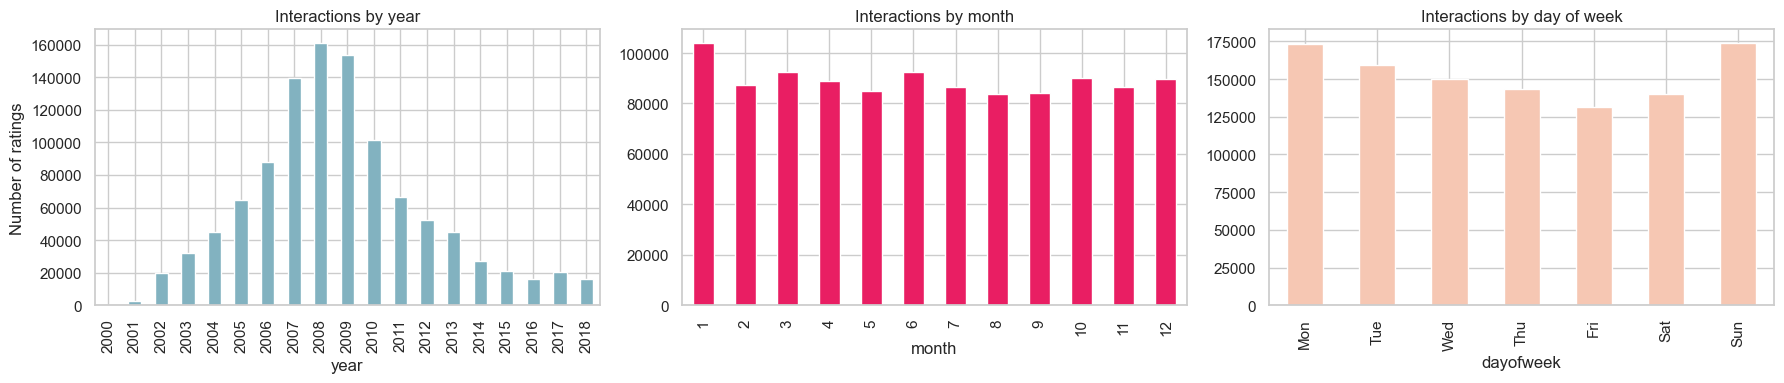

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

explicit_df.groupby('year').size().plot.bar(ax=axes[0], color=MAIN_COLOR)
axes[0].set_title('Interactions by year')
axes[0].set_ylabel('Number of ratings')

explicit_df.groupby('month').size().plot.bar(ax=axes[1], color=SECONDARY_COLOR)
axes[1].set_title('Interactions by month')

explicit_df.groupby('dayofweek').size().plot.bar(ax=axes[2], color=ACCENT_COLOR)
axes[2].set_title('Interactions by day of week')
axes[2].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()

The years 2007-2009 gather the most interactions, meaning it's when the platform was most active.
January is the month with most interactions, and mondays + sundays the weekdays.

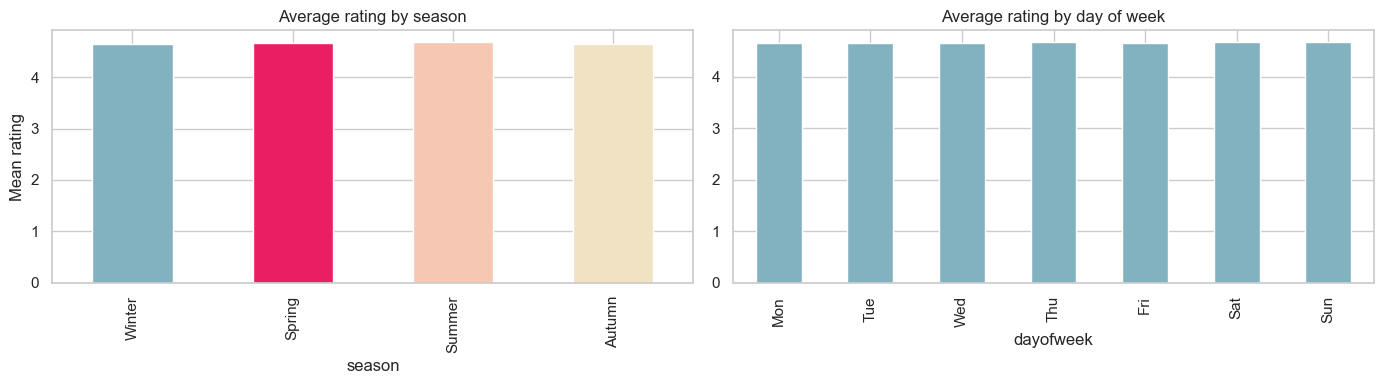

In [25]:
# Average rating by season — is there a contextual effect?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

explicit_df.groupby('season')['rating'].mean().reindex(
    ['Winter', 'Spring', 'Summer', 'Autumn']
).plot.bar(ax=axes[0], color=COLOR_MAP)
axes[0].set_title('Average rating by season')
axes[0].set_ylabel('Mean rating')

explicit_df.groupby('dayofweek')['rating'].mean().plot.bar(ax=axes[1], color=MAIN_COLOR)
axes[1].set_title('Average rating by day of week')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()

We observe that user rating patterns, remain uniform across seasons and days of the week.

### 1.9 Data filtering

We filter out users and items belonging to the long tail to create a manageable dataset for collaborative filtering, as they don't provide enough signal for pattern learning, and they artificially inflate NDCG scores.

In [26]:
MIN_USER_INTERACTIONS = 5
MIN_ITEM_INTERACTIONS = 5

# Iterative filtering (removing users can make items fall below threshold and vice versa)
ratings_filt_df = explicit_df.copy()

for iteration in range(5):
    n_before = len(ratings_filt_df)
    user_counts = ratings_filt_df.groupby('user_id').size()
    valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
    ratings_filt_df = ratings_filt_df[ratings_filt_df['user_id'].isin(valid_users)]

    item_counts = ratings_filt_df.groupby('recipe_id').size()
    valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index
    ratings_filt_df = ratings_filt_df[ratings_filt_df['recipe_id'].isin(valid_items)]

    n_after = len(ratings_filt_df)
    print(f"Iteration {iteration + 1}: {n_before:,} → {n_after:,} ratings")
    if n_before == n_after:
        break

print(f"\n── After filtering ──")
print(f"Ratings:  {len(ratings_filt_df):,}")
print(f"Users:    {ratings_filt_df['user_id'].nunique():,}")
print(f"Recipes:  {ratings_filt_df['recipe_id'].nunique():,}")
sparsity = 1 - len(ratings_filt_df) / (ratings_filt_df['user_id'].nunique() * ratings_filt_df['recipe_id'].nunique())
print(f"Sparsity: {sparsity:.4%}")

Iteration 1: 1,071,520 → 555,357 ratings
Iteration 2: 555,357 → 535,828 ratings
Iteration 3: 535,828 → 535,126 ratings
Iteration 4: 535,126 → 535,063 ratings
Iteration 5: 535,063 → 535,047 ratings

── After filtering ──
Ratings:  535,047
Users:    17,034
Recipes:  40,027
Sparsity: 99.9215%


The iterative filtering converges after 5 iterations, and reduced the dataset from 1.07M to 535K explicit ratings. This lets us focus on users/items with at least 5 interactions, ensuring CF will capture meaningful patterns. It removed ~50% of interactions resulting in 17K users × 40K recipes at 99.92% sparsity, which is a manageable but still challenging dataset.

In [27]:
# Filter recipes metadata to match
recipes_filt_df = recipes_df[recipes_df['id'].isin(ratings_filt_df['recipe_id'].unique())].copy()
print(f"Filtered recipes metadata: {len(recipes_filt_df):,} recipes")

Filtered recipes metadata: 40,027 recipes


## 2. Problem Setup

### 2.1 Surprise dataset creation

In [28]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(
    ratings_filt_df[['user_id', 'recipe_id', 'rating']].reset_index(drop=True),
    reader
)

print("Surprise dataset created ✓")
print(f"Sample raw ratings: {data.raw_ratings[:3]}")

Surprise dataset created ✓
Sample raw ratings: [(56680, 79222, 5.0, None), (183565, 79222, 5.0, None), (101823, 79222, 5.0, None)]


### 2.2 Train/test split

We use an 80/20 train-test split, the random state ensures reproducibility.

In [29]:
trainset, testset = train_test_split(data, test_size=0.20, random_state=my_seed)

print(f"Train: {trainset.n_ratings:,} ratings, {trainset.n_users:,} users, {trainset.n_items:,} items")
print(f"Test:  {len(testset):,} ratings")
print(f"Train ratio: {trainset.n_ratings / len(data.raw_ratings) * 100:.1f}%")

Train: 428,037 ratings, 17,033 users, 40,027 items
Test:  107,010 ratings
Train ratio: 80.0%


### 2.3 Relevance definition for ranking metrics

For ranking metrics (NDCG, precision@K), we defined that the threshold for an item to be relevant, on a 1–5 scale, is **4** based on the dataset nature, where ratings of 4 or 5 indicate meaningful positive preference.

In [30]:
RELEVANCE_THRESHOLD = 4
K = 10  # Top-K for ranking evaluation

test_df = pd.DataFrame(testset, columns=['user_id', 'recipe_id', 'rating'])
test_df['relevant'] = (test_df['rating'] >= RELEVANCE_THRESHOLD).astype(int)

print(f"Relevance threshold: rating >= {RELEVANCE_THRESHOLD}")
print(f"Relevant items in test: {test_df['relevant'].sum():,} / {len(test_df):,} "
      f"({test_df['relevant'].mean():.1%})")

Relevance threshold: rating >= 4
Relevant items in test: 102,123 / 107,010 (95.4%)


95.4% of test items are relevant. This extreme positive skew means ranking metrics like NDCG will be inflated for all models, so the ranking differences between models will be subtle but still informative when combined with accuracy and not-just-accuracy metrics.

### 2.4 Full trainset and anti-testset for not-accuracy metrics

For computing coverage, personalization, and diversity, we need to generate predictions for every user-item pair, not just for those in the test set, in order to do this we build the anti-testset in the full user×item space.

In [31]:
# ── Full trainset (for not-accuracy metrics) ─────────────────
# We do NOT build the full anti-testset — with 17K users × 40K items = 681M pairs,
# it causes a MemoryError. Instead, we subsample users and build per-user predictions.

trainset_full = data.build_full_trainset()

print(f"Full trainset: {trainset_full.n_ratings:,} ratings")
print(f"Users × Items = {trainset_full.n_users:,} × {trainset_full.n_items:,} = "
      f"{trainset_full.n_users * trainset_full.n_items:,} pairs")
print("(Anti-testset built per-user during evaluation to avoid MemoryError)")

Full trainset: 535,047 ratings
Users × Items = 17,034 × 40,027 = 681,819,918 pairs
(Anti-testset built per-user during evaluation to avoid MemoryError)


## 3. Non-Personalized Recommenders

We implement the baseline recommenders for comparing future models, they give the floor reference to be beaten by other models and helps us quantify added value.

### 3.1 Random Recommender

The random recommender gives our absolute baseline, it predicts a random score sampled from the training data's rating distribution and doesn't personalize at all.

In [32]:
class RandomRecommender(AlgoBase):
    """Predicts a random rating drawn from the training distribution."""

    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        ratings = [r for (_, _, r) in self.trainset.all_ratings()]
        self.train_mean = np.mean(ratings)
        self.train_std = np.std(ratings)
        return self

    def estimate(self, u, i):
        # Neither u nor i are used — no personalization
        return np.random.normal(loc=self.train_mean, scale=self.train_std)

random_RS = RandomRecommender()

In [33]:
random_RS.fit(trainset)
predictions_random = random_RS.test(testset)
accuracy.rmse(predictions_random, verbose=True)
accuracy.mae(predictions_random, verbose=True)

RMSE: 0.7625
MAE:  0.5160


0.5160399660231607

### 3.2 Popular Recommender

The popular recommender predicts the mean rating of each item across all the users who rated it, as the Random, it does not personalize, as all users receive the same score for the same item. For items which have not been seen during training, we use the global mean.

In [34]:
class PopularRecommender(AlgoBase):
    """Predicts the mean rating of each item. Falls back to global mean for unknown items."""

    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        ratings_df = pd.DataFrame(
            [[i, r] for (_, i, r) in self.trainset.all_ratings()],
            columns=['item', 'rating']
        )
        self.mean_rating_per_item_df = ratings_df.groupby('item').agg({'rating': 'mean'})
        return self

    def estimate(self, u, i):
        if i in self.mean_rating_per_item_df.index:
            return self.mean_rating_per_item_df.loc[i]['rating']
        else:
            return self.trainset.global_mean

popular_RS = PopularRecommender()

In [35]:
popular_RS.fit(trainset)
predictions_popular = popular_RS.test(testset)
accuracy.rmse(predictions_popular, verbose=True)
accuracy.mae(predictions_popular, verbose=True)

RMSE: 0.6165
MAE:  0.3957


0.39570767820683705

### 3.3 Popular Recommender with Bayesian Average

The traditional popular recommender has a problem, an item with only one 5-star rating would seem more popular than an item with more ratings but lowe average (4.9 stars). The **Bayesian average** addresses this by adding a penalty for items with few ratings, so they are pulled towards the global mean.

$$\text{Bayesian Average} = \frac{v \cdot R + m \cdot C}{v + m}$$

Where: $v$ = number of votes for the item, $R$ = mean rating of the item, $C$ = global mean, $m$ = minimum votes threshold (we use the median).

In [36]:
class BayesianPopularRecommender(AlgoBase):
    """Popular recommender using Bayesian average to penalize items with few ratings."""

    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        C = trainset.global_mean  # Prior (global mean)

        # Compute item stats
        item_stats = {}
        for iid in trainset.all_items():
            ratings = [r for (_, r) in trainset.ir[iid]]
            item_stats[iid] = {'mean': np.mean(ratings), 'count': len(ratings)}

        m = np.median([s['count'] for s in item_stats.values()])  # Confidence threshold
        self.m = m
        self.C = C

        # Bayesian average per item
        self.bayesian_score = {}
        for iid, stats in item_stats.items():
            v, R = stats['count'], stats['mean']
            self.bayesian_score[iid] = (v * R + m * C) / (v + m)

        return self

    def estimate(self, u, i):
        if i in self.bayesian_score:
            return self.bayesian_score[i]
        return self.trainset.global_mean

bayesian_RS = BayesianPopularRecommender()

In [37]:
bayesian_RS.fit(trainset)
predictions_bayesian = bayesian_RS.test(testset)
accuracy.rmse(predictions_bayesian, verbose=True)
accuracy.mae(predictions_bayesian, verbose=True)

print(f"\nBayesian params: C (global mean) = {bayesian_RS.C:.3f}, m (median votes) = {bayesian_RS.m:.0f}")

RMSE: 0.5982
MAE:  0.4066

Bayesian params: C (global mean) = 4.730, m (median votes) = 6


The Bayesian Popular achieves a lower RMSE (0.598) than the plain Popular (0.617) because of the penalization, which reduces extreme prediction errors from high-rated items with low support. The median vote threshold (m=6) means items with fewer than 6 ratings are regularized.

### 3.4 SVD Baseline (Collaborative Filtering reference)

We include a basic SVD model as a reference point for collaborative filtering beforediving deeper (memory-based + model-based with hyperparameter tuning). We used defaults to establish the performance gap between non-personalized and personalized approaches.

In [38]:
svd_baseline = SVD(random_state=my_seed)

svd_baseline.fit(trainset)
predictions_svd = svd_baseline.test(testset)
accuracy.rmse(predictions_svd, verbose=True)
accuracy.mae(predictions_svd, verbose=True)

RMSE: 0.5655
MAE:  0.3587


0.3586903297705164

### 3.5 Comparison: Regression perspective

We compare the predictions of all recommenders using violin plots, which illustrate the distribution of the predicted ratings for each true rating value, so we can see how well each recommender differenciates between different rating levels.

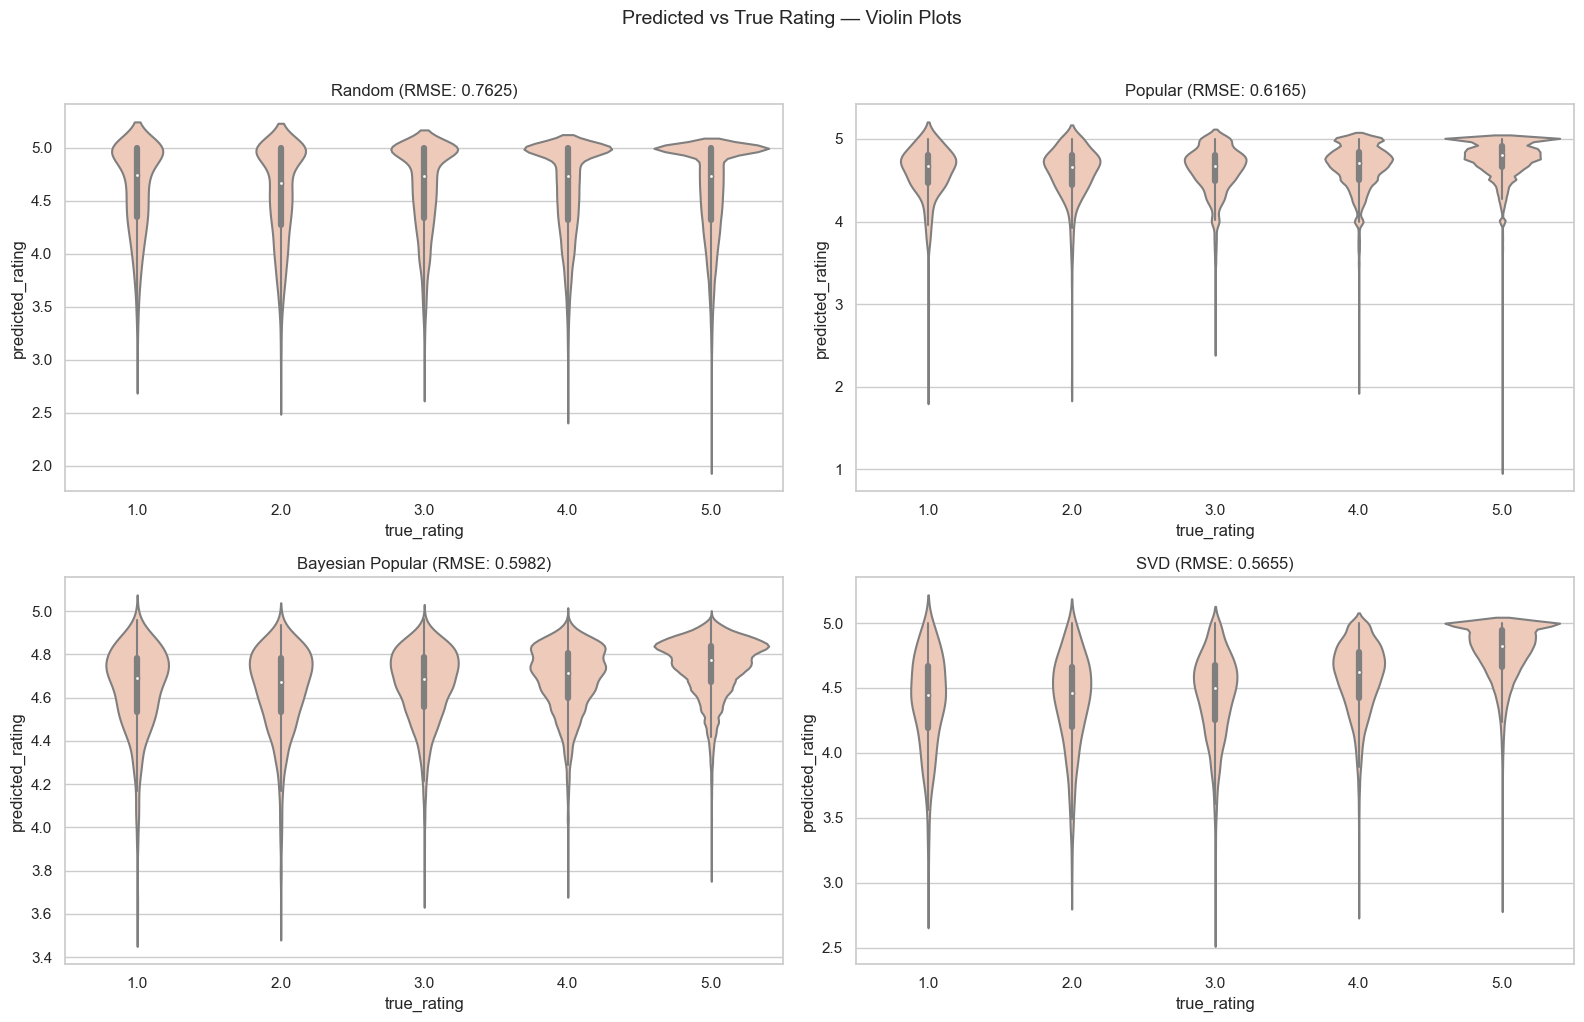

In [39]:
columns = ['user', 'item', 'true_rating', 'predicted_rating', 'details']
all_preds = {
    'Random': predictions_random,
    'Popular': predictions_popular,
    'Bayesian Popular': predictions_bayesian,
    'SVD': predictions_svd
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (name, preds) in zip(axes.flatten(), all_preds.items()):
    pred_df = pd.DataFrame(preds, columns=columns)
    sns.violinplot(data=pred_df, x="true_rating", y="predicted_rating", ax=ax, color=ACCENT_COLOR)
    rmse = np.sqrt(metrics.mean_squared_error(pred_df['true_rating'], pred_df['predicted_rating']))
    ax.set_title(f'{name} (RMSE: {rmse:.4f})')

plt.suptitle('Predicted vs True Rating — Violin Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

These illustrate the improvement from Random (no discrimination between true ratings) → Popular (slight trend) → SVD (better separation). The Popular recommender simply predicts near the mean, SVD however, shows wider spread and better alignment with true ratings, demonstrating the value of personalization.

### 3.6 Cross-validation

To ger better performance estimates, we ran a 5-fold cross-validation, accounting for potential luck in a single train-test split.

In [40]:
print("=" * 70)
print("5-Fold Cross-Validation Results")
print("=" * 70)

cv_results = {}
for name, rs in [('Random', RandomRecommender()),
                  ('Popular', PopularRecommender()),
                  ('Bayesian', BayesianPopularRecommender()),
                  ('SVD', SVD(random_state=my_seed))]:
    print(f"\n── {name} ──")
    perf = cross_validate(rs, data, measures=['RMSE', 'MAE'],
                          cv=KFold(n_splits=5, random_state=my_seed),
                          return_train_measures=True, verbose=True)
    cv_results[name] = {
        'RMSE_train': np.mean(perf['train_rmse']),
        'RMSE_test': np.mean(perf['test_rmse']),
        'MAE_test': np.mean(perf['test_mae']),
    }

cv_df = pd.DataFrame(cv_results).T
cv_df.columns = ['RMSE (train)', 'RMSE (test)', 'MAE (test)']
print("\n── Summary ──")
cv_df

5-Fold Cross-Validation Results

── Random ──
Evaluating RMSE, MAE of algorithm RandomRecommender on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.7626  0.7612  0.7625  0.7647  0.7623  0.7627  0.0011  
MAE (testset)     0.5170  0.5153  0.5183  0.5189  0.5165  0.5172  0.0013  
RMSE (trainset)   0.7633  0.7642  0.7629  0.7612  0.7631  0.7629  0.0010  
MAE (trainset)    0.5176  0.5179  0.5168  0.5155  0.5171  0.5170  0.0008  
Fit time          0.39    0.53    0.45    0.52    0.52    0.48    0.05    
Test time         0.35    0.32    0.30    0.30    0.31    0.32    0.02    

── Popular ──
Evaluating RMSE, MAE of algorithm PopularRecommender on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.6147  0.6154  0.6133  0.6200  0.6165  0.6160  0.0023  
MAE (testset)     0.3948  0.3957  0.3947  0.3973  0.3957  0.3956  0.0009  
RMSE (trainset)   0.5590  0.5588  0.5593  0.5578  0.

,RMSE (train),RMSE (test),MAE (test)
Random,0.762913,0.762680,0.517195
Popular,0.558657,0.615971,0.395634
Bayesian,0.568592,0.597597,0.406569
SVD,0.436470,0.565717,0.358746


## 4. Evaluation Framework

We implement evaluation as covered in the course: regression, classification, ranking, and not-just-accuracy metrics.

### 4.1 Utility: get_top_n

In [41]:
def get_top_n(predictions, n=10, solve_ties=False):
    """Return the top-N recommendations for each user.

    Args:
        predictions: list of Prediction objects from surprise
        n: number of recommendations per user
        solve_ties: if True, ties are broken by item id (deterministic)

    Returns:
        dict: {user_id: [(item_id, estimated_rating), ...]}
    """
    from collections import defaultdict
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():
        if solve_ties:
            user_ratings.sort(key=lambda x: (x[1], x[0]), reverse=True)
        else:
            user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

### 4.2 NDCG evaluation

We skip users with fewer than 2 items in the test set, because NDCG is undefined for them, and we also provide a version where we evaluate users only with a minimum number of test items to check the actual gap.

In [42]:
def ndcg_multiple_users(relevant_items_all_users, predictions_ranking_all_users, k=10):
    """Compute average NDCG@K across all users.

    Args:
        relevant_items_all_users: list of lists with true ratings per user
        predictions_ranking_all_users: list of lists with predicted ratings per user
        k: cutoff for NDCG

    Returns:
        float: mean NDCG@K
    """
    ndcg_list = []
    for i in range(len(relevant_items_all_users)):
        # Skip users with only 1 item — NDCG is not meaningful
        if len(relevant_items_all_users[i]) > 1:
            ndcg = metrics.ndcg_score(
                [relevant_items_all_users[i]],
                [predictions_ranking_all_users[i]],
                k=k
            )
            ndcg_list.append(ndcg)
    return np.mean(ndcg_list) if ndcg_list else 0.0


def evaluate_ndcg(predictions, k=10):
    """Compute NDCG@K from Surprise predictions."""
    pred_df = pd.DataFrame(predictions)
    pred_df['est'] = pred_df['est'].round(4)
    pred_byuser = pred_df.groupby('uid')[['iid', 'r_ui', 'est']].agg(lambda x: list(x))
    return ndcg_multiple_users(
        pred_byuser['r_ui'].tolist(),
        pred_byuser['est'].tolist(),
        k=k
    )


def evaluate_ndcg_filtered(predictions, min_items=5, k=10):
    """NDCG@K only for users with >= min_items in the test set.

    Following the Aux notebook: filtering out users with very few test items
    reveals the true ranking quality difference between recommenders.
    """
    pred_df = pd.DataFrame(predictions)
    user_counts = pred_df.groupby('uid').size()
    valid_users = user_counts[user_counts >= min_items].index
    pred_filt = pred_df[pred_df['uid'].isin(valid_users)]
    pred_byuser = pred_filt.groupby('uid')[['iid', 'r_ui', 'est']].agg(lambda x: list(x))

    if len(pred_byuser) == 0:
        return 0.0
    return ndcg_multiple_users(
        pred_byuser['r_ui'].tolist(),
        pred_byuser['est'].tolist(),
        k=k
    )

### 4.3 Ranking evaluation of baselines

In [43]:
print("── NDCG Evaluation ──")
print(f"{'Model':<22} {'NDCG@10':>10} {'NDCG@10 (≥5 items)':>22}")
print("-" * 56)

for name, preds in all_preds.items():
    ndcg_all = evaluate_ndcg(preds, k=K)
    ndcg_filt = evaluate_ndcg_filtered(preds, min_items=5, k=K)
    print(f"{name:<22} {ndcg_all:>10.4f} {ndcg_filt:>22.4f}")

── NDCG Evaluation ──
Model                     NDCG@10     NDCG@10 (≥5 items)
--------------------------------------------------------
Random                     0.9784                 0.9677
Popular                    0.9839                 0.9762
Bayesian Popular           0.9849                 0.9783
SVD                        0.9835                 0.9759


When we evaluate NDCG for all users, values are similar across recommenders, this is because many users have very few test items, making the ranking too easy. To show the actual difference between models, we filter to users with at least 20 test items.

In [44]:
# ── NDCG by minimum test items (Aux notebook approach) ───────
# The Aux notebook shows that filtering users by their number of test items
# reveals the true ranking quality gap between recommenders.

print("── NDCG@10 filtered by minimum number of test items ──")
print(f"{'Model':<22} {'All':>8} {'≥2':>8} {'≥5':>8} {'≥10':>8} {'≥20':>8}")
print("-" * 62)

# Pre-compute user test item counts
user_test_counts = pd.DataFrame(testset, columns=['uid', 'iid', 'rating']).groupby('uid').size()

for name, preds in all_preds.items():
    pred_df = pd.DataFrame(preds)
    results = []

    for min_items in [1, 2, 5, 10, 20]:
        valid_users = user_test_counts[user_test_counts >= min_items].index
        pred_filt = pred_df[pred_df['uid'].isin(valid_users)]

        if len(pred_filt) == 0:
            results.append(0.0)
            continue

        pred_byuser = pred_filt.groupby('uid')[['iid', 'r_ui', 'est']].agg(lambda x: list(x))
        ndcg_val = ndcg_multiple_users(
            pred_byuser['r_ui'].tolist(),
            pred_byuser['est'].tolist(),
            k=K
        )
        results.append(ndcg_val)

    print(f"{name:<22} {results[0]:>8.4f} {results[1]:>8.4f} {results[2]:>8.4f} "
          f"{results[3]:>8.4f} {results[4]:>8.4f}")

# Show how many users pass each threshold
print(f"\n{'Users at threshold':<22} ", end="")
for min_items in [1, 2, 5, 10, 20]:
    n = (user_test_counts >= min_items).sum()
    print(f"{n:>8,}", end="")
print()

── NDCG@10 filtered by minimum number of test items ──
Model                       All       ≥2       ≥5      ≥10      ≥20
--------------------------------------------------------------
Random                   0.9784   0.9784   0.9677   0.9531   0.9472
Popular                  0.9839   0.9839   0.9762   0.9651   0.9618
Bayesian Popular         0.9849   0.9849   0.9783   0.9686   0.9676
SVD                      0.9835   0.9835   0.9759   0.9649   0.9620

Users at threshold       14,826  11,073   4,560   2,106     982


### 4.4 Not-just-accuracy metrics: Coverage, Personalization, Diversity

We compute coverage, personalization, and diversity metrics using the previously computed anti-test set.

In [45]:
# ── Not-accuracy metrics ─────────────────────────────────────
# We compute top-N directly from model scores (bypassing Surprise's slow .test())
# This is mathematically equivalent but runs in seconds instead of hours.

import gc
from collections import defaultdict

TOP_N = 50

# Use the full trainset
trainset_cov = data.build_full_trainset()
catalog = [trainset_cov.to_raw_iid(iid) for iid in trainset_cov.all_items()]
all_inner_items = np.array(list(trainset_cov.all_items()))

# Subsample 5% of users
all_inner_users = list(trainset_cov.all_users())
np.random.seed(my_seed)
sample_size = max(1, int(len(all_inner_users) * 0.05))
sampled_users = np.random.choice(all_inner_users, size=sample_size, replace=False)

print(f"Evaluating not-accuracy metrics on {sample_size} users (5% of {len(all_inner_users):,})")
print(f"Catalog size: {len(catalog):,} items")

# ── Pre-compute model scores ─────────────────────────────────
# Popular scores
popular_model = PopularRecommender()
popular_model.fit(trainset_cov)
popular_scores = np.full(trainset_cov.n_items, trainset_cov.global_mean)
for iid in trainset_cov.all_items():
    if iid in popular_model.mean_rating_per_item_df.index:
        popular_scores[iid] = popular_model.mean_rating_per_item_df.loc[iid]['rating']

# Bayesian scores
bayesian_model = BayesianPopularRecommender()
bayesian_model.fit(trainset_cov)
bayesian_scores = np.full(trainset_cov.n_items, trainset_cov.global_mean)
for iid in trainset_cov.all_items():
    if iid in bayesian_model.bayesian_score:
        bayesian_scores[iid] = bayesian_model.bayesian_score[iid]

# SVD scores (vectorized: score = mu + bu + bi + pu @ qi.T)
svd_model = SVD(random_state=my_seed)
svd_model.fit(trainset_cov)

print("All model scores pre-computed ✓")

# ── Generate top-N per user ──────────────────────────────────
top_n_items = {name: [] for name in ['Random', 'Popular', 'Bayesian Pop.', 'SVD (baseline)']}

for uid in tqdm(sampled_users, desc="Computing top-N"):
    # Items this user has NOT rated
    user_rated = {j for (j, _) in trainset_cov.ur[uid]}
    mask = np.array([iid not in user_rated for iid in all_inner_items])
    candidates = all_inner_items[mask]

    if len(candidates) < TOP_N:
        continue

    # Random: truly random selection (no scoring bias)
    rng_idx = np.random.choice(len(candidates), size=TOP_N, replace=False)
    top_n_items['Random'].append([trainset_cov.to_raw_iid(candidates[i]) for i in rng_idx])

    # Popular
    scores = popular_scores[candidates]
    top_idx = np.argpartition(scores, -TOP_N)[-TOP_N:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    top_n_items['Popular'].append([trainset_cov.to_raw_iid(candidates[i]) for i in top_idx])

    # Bayesian
    scores = bayesian_scores[candidates]
    top_idx = np.argpartition(scores, -TOP_N)[-TOP_N:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    top_n_items['Bayesian Pop.'].append([trainset_cov.to_raw_iid(candidates[i]) for i in top_idx])

    # SVD (vectorized)
    scores = (svd_model.trainset.global_mean
              + svd_model.bu[uid]
              + svd_model.bi[candidates]
              + svd_model.pu[uid] @ svd_model.qi[candidates].T)
    top_idx = np.argpartition(scores, -TOP_N)[-TOP_N:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    top_n_items['SVD (baseline)'].append([trainset_cov.to_raw_iid(candidates[i]) for i in top_idx])

print(f"\nDone! {sample_size} users × top-{TOP_N} for 4 models ✓")

Evaluating not-accuracy metrics on 851 users (5% of 17,034)
Catalog size: 40,027 items
All model scores pre-computed ✓


Computing top-N: 100%|██████████| 851/851 [00:21<00:00, 38.74it/s]


Done! 851 users × top-50 for 4 models ✓


#### Coverage & Personalization

Through coverage we measure what fraction of the catalog is shown in any user's recommendation list. Random achieves high coverage as any item can be potentially selected, while Popular achieves very low coverage (it shows the same head items for everyone).

Personalization is used to measuree how different the recommendation lists are across users. Popular for instance, has zero personalization (everyone gets the same list), Random shows high personalization but it's not meaningful (random items are likely different accross users), while a good CF model should produce different accurate lists for different users.

In [46]:
# ── Compute coverage, personalization ─────────────────────────
print(f"{'Model':<22} {'Coverage (%)':>14} {'Personalization':>16}")
print("-" * 54)

coverage_scores = {}
personalization_scores = {}

for name in ['Random', 'Popular', 'Bayesian Pop.', 'SVD (baseline)']:
    cov = recmetrics.prediction_coverage(top_n_items[name], catalog)
    pers = recmetrics.personalization(top_n_items[name])
    coverage_scores[name] = cov
    personalization_scores[name] = pers
    print(f"{name:<22} {cov:>14.2f} {pers:>16.4f}")

# Save for later use
coverage_random = coverage_scores['Random']
coverage_popular = coverage_scores['Popular']
coverage_bayesian = coverage_scores['Bayesian Pop.']
coverage_svd = coverage_scores['SVD (baseline)']
personalization_random = personalization_scores['Random']
personalization_popular = personalization_scores['Popular']
personalization_bayesian = personalization_scores['Bayesian Pop.']
personalization_svd = personalization_scores['SVD (baseline)']

Model                    Coverage (%)  Personalization
------------------------------------------------------
Random                          65.16           0.9987
Popular                         10.90           0.9460
Bayesian Pop.                    0.14           0.0056
SVD (baseline)                  22.99           0.9784


* **Random (65%)**: picks different items per user by design
* **SVD (23%)**: personalizes via latent factors, surfaces different items per user
* **Popular (11%)**: some variance in item mean ratings creates mild differentiation
* **Bayesian (0.14%)**: actively compresses scores → same top items for everyone

#### Diversity

Diversity (intra-list similarity) measures how similar/varied the recommended items within a single user list are, to compute this we used the tag-based one-hot encoding of recipes.

In [47]:
# ── Build tag one-hot matrix ───────
# Use top-50 most common tags to keep it manageable
top_tags = tags_exploded['tag'].value_counts().head(50).index.tolist()

tags_onehot = recipes_filt_df[['id']].copy()
for tag in top_tags:
    tags_onehot[tag] = recipes_filt_df['tags_parsed'].apply(
        lambda x: 1 if tag in x else 0
    )
tags_onehot = tags_onehot.set_index('id')

print(f"Tags one-hot matrix: {tags_onehot.shape}")
tags_onehot.head()

Tags one-hot matrix: (40027, 50)


,preparation,time-to-make,course,main-ingredient,dietary,easy,occasion,cuisine,low-in-something,main-dish,...,kid-friendly,side-dishes,healthy-2,comfort-food,european,presentation,poultry,lunch,for-1-or-2,low-fat
id,,,,,,,,,,,,,,,,,,,,,
63986,1,1,1,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
43026,1,1,1,1,1,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
23933,1,1,1,0,1,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
54100,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
67664,1,1,1,0,1,1,1,0,1,0,...,1,0,1,0,0,0,0,1,0,1


In [48]:
diversity_random  = recmetrics.intra_list_similarity(top_n_items['Random'], tags_onehot)
diversity_popular = recmetrics.intra_list_similarity(top_n_items['Popular'], tags_onehot)
diversity_bayesian = recmetrics.intra_list_similarity(top_n_items['Bayesian Pop.'], tags_onehot)
diversity_svd     = recmetrics.intra_list_similarity(top_n_items['SVD (baseline)'], tags_onehot)

print(f"Intra-list similarity (lower = more diverse):")
print(f"  Random: {diversity_random:.4f}, Popular: {diversity_popular:.4f}, "
      f"Bayesian: {diversity_bayesian:.4f}, SVD: {diversity_svd:.4f}")

Intra-list similarity (lower = more diverse):
  Random: 0.4825, Popular: 0.4740, Bayesian: 0.4615, SVD: 0.4839


Intra-list similarity values are similar across all models (0.46–0.48), so within-user diversity is comparable, this makes sense as diversity depends more on the item catalog structure than the recommendation algorithm.

### 4.5 Summary of baseline results

In [49]:
# ── Build comprehensive comparison table ──────────────────────
summary_data = {
    'Random': {
        'RMSE': accuracy.rmse(predictions_random, verbose=False),
        'MAE': accuracy.mae(predictions_random, verbose=False),
        'NDCG@10': evaluate_ndcg(predictions_random, k=K),
        'NDCG@10 (≥20)': evaluate_ndcg_filtered(predictions_random, min_items=20, k=K),
        'Coverage (%)': coverage_random,
        'Personalization': personalization_random,
        'ILS (diversity)': diversity_random,
    },
    'Popular': {
        'RMSE': accuracy.rmse(predictions_popular, verbose=False),
        'MAE': accuracy.mae(predictions_popular, verbose=False),
        'NDCG@10': evaluate_ndcg(predictions_popular, k=K),
        'NDCG@10 (≥20)': evaluate_ndcg_filtered(predictions_popular, min_items=20, k=K),
        'Coverage (%)': coverage_popular,
        'Personalization': personalization_popular,
        'ILS (diversity)': diversity_popular,
    },
    'Bayesian Pop.': {
        'RMSE': accuracy.rmse(predictions_bayesian, verbose=False),
        'MAE': accuracy.mae(predictions_bayesian, verbose=False),
        'NDCG@10': evaluate_ndcg(predictions_bayesian, k=K),
        'NDCG@10 (≥20)': evaluate_ndcg_filtered(predictions_bayesian, min_items=20, k=K),
        'Coverage (%)': coverage_bayesian,
        'Personalization': personalization_bayesian,
        'ILS (diversity)': diversity_bayesian,
    },
    'SVD (baseline)': {
        'RMSE': accuracy.rmse(predictions_svd, verbose=False),
        'MAE': accuracy.mae(predictions_svd, verbose=False),
        'NDCG@10': evaluate_ndcg(predictions_svd, k=K),
        'NDCG@10 (≥20)': evaluate_ndcg_filtered(predictions_svd, min_items=20, k=K),
        'Coverage (%)': coverage_svd,
        'Personalization': personalization_svd,
        'ILS (diversity)': diversity_svd,
    }
}

results_df = pd.DataFrame(summary_data).T
results_df = results_df.round(4)
print("\n══════════════════════════════════════════════════════════════")
print("          COMPREHENSIVE BASELINE COMPARISON")
print("══════════════════════════════════════════════════════════════")
results_df


══════════════════════════════════════════════════════════════
          COMPREHENSIVE BASELINE COMPARISON
══════════════════════════════════════════════════════════════


,RMSE,MAE,NDCG@10,NDCG@10 (≥20),Coverage (%),Personalization,ILS (diversity)
Random,0.7625,0.5160,0.9784,0.9472,65.16,0.9987,0.4825
Popular,0.6165,0.3957,0.9839,0.9618,10.90,0.9460,0.4740
Bayesian Pop.,0.5982,0.4066,0.9849,0.9676,0.14,0.0056,0.4615
SVD (baseline),0.5655,0.3587,0.9835,0.9620,22.99,0.9784,0.4839


In [50]:
# ── Radar/Summary plot ────────────────────────────────────────
model_names = ['Random', 'Popular', 'Bayesian Pop.', 'SVD (baseline)']
recmetrics.metrics_plot(
    model_names=model_names,
    coverage_scores=[coverage_random, coverage_popular, coverage_bayesian, coverage_svd],
    personalization_scores=[personalization_random, personalization_popular,
                            personalization_bayesian, personalization_svd],
    intra_list_similarity_scores=[diversity_random, diversity_popular,
                                  diversity_bayesian, diversity_svd]
)

**Key observations:**
- **Random**: Worst accuracy (highest RMSE), but best coverage and personalization — because it spreads items randomly across users
- **Popular**: Competitive RMSE (strong baseline), but zero personalization and low coverage — everyone gets the same top items
- **Bayesian Popular**: Slightly different from Popular due to penalization, but same limitations
- **SVD**: Best accuracy, good personalization and reasonable coverage — demonstrates the value of collaborative filtering

## 5. Bonus: Cross-Validation Through Time (CVTT)

Instead of randomly splitting, we tran on data from the past and test on future data, enabling a real deployment simularion where historical data is used to predict future preferences. The SVD model is now evaluated using time-aware splits.

In [51]:
from sklearn.model_selection import TimeSeriesSplit

# Sort by date
ratings_sorted = ratings_filt_df.sort_values('date').reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
cvtt_results = []

fold = 1
for train_index, test_index in tscv.split(ratings_sorted):
    train_fold = ratings_sorted.loc[train_index]
    test_fold = ratings_sorted.loc[test_index]

    train_min = train_fold['date'].min().strftime('%Y-%m-%d')
    train_max = train_fold['date'].max().strftime('%Y-%m-%d')
    test_min = test_fold['date'].min().strftime('%Y-%m-%d')
    test_max = test_fold['date'].max().strftime('%Y-%m-%d')

    print(f"Fold {fold}: Train {train_fold.shape[0]:,} ratings ({train_min} to {train_max}) | "
          f"Test {test_fold.shape[0]:,} ratings ({test_min} to {test_max})")

    # Build Surprise datasets for this fold
    train_data = Dataset.load_from_df(
        train_fold[['user_id', 'recipe_id', 'rating']], reader
    ).build_full_trainset()

    # Only test on users/items that exist in training
    known_users = {train_data.to_raw_uid(u) for u in train_data.all_users()}
    known_items = {train_data.to_raw_iid(i) for i in train_data.all_items()}
    test_surprise = [(uid, iid, r) for uid, iid, r in
                     test_fold[['user_id', 'recipe_id', 'rating']].values
                     if uid in known_users and iid in known_items]

    if len(test_surprise) > 0:
        algo = SVD(random_state=my_seed)
        algo.fit(train_data)
        preds = algo.test(test_surprise)
        rmse_val = accuracy.rmse(preds, verbose=False)
        ndcg_val = evaluate_ndcg(preds, k=K)
        cvtt_results.append({'fold': fold, 'rmse': rmse_val, 'ndcg': ndcg_val,
                             'test_size': len(test_surprise)})

    fold += 1

cvtt_df = pd.DataFrame(cvtt_results)
print(f"\nCVTT Average — RMSE: {cvtt_df['rmse'].mean():.4f}, NDCG@{K}: {cvtt_df['ndcg'].mean():.4f}")
cvtt_df

Fold 1: Train 89,177 ratings (2000-09-12 to 2005-11-25) | Test 89,174 ratings (2005-11-25 to 2007-06-13)
Fold 2: Train 178,351 ratings (2000-09-12 to 2007-06-13) | Test 89,174 ratings (2007-06-13 to 2008-06-18)
Fold 3: Train 267,525 ratings (2000-09-12 to 2008-06-18) | Test 89,174 ratings (2008-06-18 to 2009-07-01)
Fold 4: Train 356,699 ratings (2000-09-12 to 2009-07-01) | Test 89,174 ratings (2009-07-01 to 2011-01-06)
Fold 5: Train 445,873 ratings (2000-09-12 to 2011-01-06) | Test 89,174 ratings (2011-01-06 to 2018-12-18)

CVTT Average — RMSE: 0.5816, NDCG@10: 0.9799


,fold,rmse,ndcg,test_size
0,1,0.566185,0.978336,38040
1,2,0.616851,0.976600,51934
2,3,0.565467,0.981061,61792
3,4,0.577008,0.982473,69034
4,5,0.582289,0.981175,68602


RMSE remains more or less stable across folds (0.57–0.62), with a slight increase in Fold 2 (0.617) likely because user behaviour varied in that period. As expected, the average CVTT RMSE (0.582) is slightly higher than the standard CV RMSE (0.566), normally splits based on time are harder as the model can't learn from future patterns. 

This confirms that our evaluation is realistic and the model generalizes to future data.

## 6. Shared Data Exports

This section exports the processed data and evaluation functions so they can be imported directly.

In [52]:
# ── Save filtered datasets ────────────────────────────────────
ratings_filt_df.to_csv('ratings_filtered.csv', index=False)
recipes_filt_df.to_csv('recipes_filtered.csv', index=False)

print("Exported:")
print(f"  ratings_filtered.csv  — {len(ratings_filt_df):,} rows")
print(f"  recipes_filtered.csv  — {len(recipes_filt_df):,} rows")
print(f"\nShared constants:")
print(f"  my_seed = {my_seed}")
print(f"  RELEVANCE_THRESHOLD = {RELEVANCE_THRESHOLD}")
print(f"  K = {K}")
print(f"  Reader: rating_scale=(1, 5)")
print(f"\nShared functions: get_top_n(), ndcg_multiple_users(), evaluate_ndcg(), evaluate_ndcg_filtered()")
print(f"\nShared objects: data, trainset, testset, trainset_full, catalog, tags_onehot")

Exported:
  ratings_filtered.csv  — 535,047 rows
  recipes_filtered.csv  — 40,027 rows

Shared constants:
  my_seed = 42
  RELEVANCE_THRESHOLD = 4
  K = 10
  Reader: rating_scale=(1, 5)

Shared functions: get_top_n(), ndcg_multiple_users(), evaluate_ndcg(), evaluate_ndcg_filtered()

Shared objects: data, trainset, testset, trainset_full, catalog, tags_onehot


## 7. Collaborative Filtering Recommenders
*[Person 2 — memory-based (user-based KNN, item-based KNN) + model-based (SVD with hyperparameter tuning, overfitting analysis)]*


## 8. Content-Based Recommender

### 8.1 Metadata Preparation

In [55]:
cb_recipes = recipes_filt_df.copy()
cb_recipes = cb_recipes.set_index("id")

# ── Parse nutrition → 7 numerical columns ────────────────────────────────────
# Raw format: "[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]"
nutrition_cols = ["calories", "fat", "sugar", "sodium", "protein", "sat_fat", "carbs"]
nutrition_parsed = cb_recipes["nutrition"].apply(ast.literal_eval)
cb_recipes[nutrition_cols] = pd.DataFrame(nutrition_parsed.tolist(),
                                           index=cb_recipes.index)

# ── Parse tags → joined string for vectorization ──────────────────────────────
# Raw format: "['60-minutes-or-less', 'vegetarian', 'main-dish']"
# We join into a space-separated string so CountVectorizer can read it
cb_recipes["tags_str"] = cb_recipes["tags"].apply(
    lambda x: " ".join(ast.literal_eval(x))
)

# ── Build text column: name + description ─────────────────────────────────────
# Some recipes have no description — we fall back to name only
cb_recipes["description"] = cb_recipes["description"].fillna("")
cb_recipes["text_for_nlp"] = (cb_recipes["name"].fillna("") + " " +
                               cb_recipes["description"])

# ── Final numerical columns list (for similarity) ────────────────────────────
num_cols = ["minutes", "n_steps", "n_ingredients"] + nutrition_cols

print(f"cb_recipes ready: {cb_recipes.shape}")
print(f"\nNumerical columns : {num_cols}")
print(f"Categorical column: tags_str")
print(f"Text column       : text_for_nlp")
print(f"\nMissing values:")
for col in ["tags_str", "text_for_nlp"] + num_cols:
    print(f"  {col:<20}: {cb_recipes[col].isna().sum()} missing")

cb_recipes ready: (40027, 30)

Numerical columns : ['minutes', 'n_steps', 'n_ingredients', 'calories', 'fat', 'sugar', 'sodium', 'protein', 'sat_fat', 'carbs']
Categorical column: tags_str
Text column       : text_for_nlp

Missing values:
  tags_str            : 0 missing
  text_for_nlp        : 0 missing
  minutes             : 0 missing
  n_steps             : 0 missing
  n_ingredients       : 0 missing
  calories            : 0 missing
  fat                 : 0 missing
  sugar               : 0 missing
  sodium              : 0 missing
  protein             : 0 missing
  sat_fat             : 0 missing
  carbs               : 0 missing


### 8.2 Numerical Similarity

In [56]:
# ── Step 1: Normalize numerical columns ──────────────────────────────────────
# Without normalization, calories (can be 1000+) would dominate over n_steps (1-50)
scaler = StandardScaler()
num_matrix = scaler.fit_transform(cb_recipes[num_cols])

# ── Step 2: Compute cosine similarity matrix ──────────────────────────────────
# Result is a (40027 x 40027) matrix — each cell is the similarity between two recipes
print("Computing numerical similarity matrix...")
num_sim = cosine_similarity(num_matrix)
print(f"Numerical similarity matrix shape: {num_sim.shape}")

# ── Step 3: Wrap in a DataFrame with recipe IDs as index/columns ──────────────
recipe_ids = cb_recipes.index.tolist()
num_sim_df = pd.DataFrame(num_sim, index=recipe_ids, columns=recipe_ids)

# ── Helper: get most similar recipes to a given recipe ───────────────────────
def get_similar_recipes(recipe_id, sim_df, n=10):
    """Return top-n most similar recipes to recipe_id (excluding itself).
    
    Args:
        recipe_id : the recipe ID to query
        sim_df    : similarity DataFrame (recipes x recipes)
        n         : number of similar recipes to return
    
    Returns:
        pd.Series with recipe_id index and similarity score values
    """
    if recipe_id not in sim_df.index:
        print(f"Recipe {recipe_id} not found in similarity matrix.")
        return pd.Series(dtype=float)
    
    # Sort by similarity score descending, exclude the recipe itself
    similar = sim_df[recipe_id].drop(index=recipe_id).sort_values(ascending=False)
    return similar.head(n)

# ── Quick sanity check: find similar recipes to the first recipe ──────────────
sample_id = recipe_ids[0]
sample_name = cb_recipes.loc[sample_id, "name"]
print(f"\nSample recipe: '{sample_name}' (id={sample_id})")
print(f"\nTop 5 most similar recipes by numerical features:")

similar = get_similar_recipes(sample_id, num_sim_df, n=5)
for rid, score in similar.items():
    name = cb_recipes.loc[rid, "name"]
    print(f"  [{rid}] {name:<45} similarity: {score:.4f}")

Computing numerical similarity matrix...
Numerical similarity matrix shape: (40027, 40027)

Sample recipe: 'chicken lickin  good  pork chops' (id=63986)

Top 5 most similar recipes by numerical features:
  [201257] lemony green beans                            similarity: 0.9986
  [13949] cube steak and gravy  crock pot               similarity: 0.9972
  [198003] sauteed green beans and red onion             similarity: 0.9971
  [295489] award winning guacamole                       similarity: 0.9971
  [83478] marinade for steak                            similarity: 0.9960


### 8.3 Categorical Similarities

In [67]:
# ── Step 1: Vectorize tags ────────────────────────────────────────────────────
cat_vectorizer = CountVectorizer(token_pattern=r"[a-z0-9][a-z0-9\-]+")
cat_matrix = cat_vectorizer.fit_transform(cb_recipes["tags_str"])

print(f"Tag vocabulary size : {len(cat_vectorizer.vocabulary_):,} unique tags")
print(f"Tag matrix shape    : {cat_matrix.shape}")

# ── Step 2: L2-normalize rows (so dot product = cosine similarity) ────────────
# We store the normalized matrix in float32 to save memory
cat_matrix_norm = normalize(cat_matrix, norm="l2").astype("float32")

# ── Helper: get similar recipes on demand ────────────────────────────────────
def get_similar_recipes_sparse(recipe_id, matrix_norm, n=10):
    """Compute cosine similarity for one recipe against all others on the fly.
    Works with both sparse matrices (BoW, TF-IDF, tags) and dense arrays (BERT).
    """
    if recipe_id not in cb_recipes.index:
        print(f"Recipe {recipe_id} not found.")
        return pd.Series(dtype=float)

    idx = recipe_ids.index(recipe_id)
    row = matrix_norm[idx]

    # Handle sparse vs dense
    if sparse.issparse(matrix_norm):
        scores = (matrix_norm @ row.T).toarray().flatten()
    else:
        scores = (matrix_norm @ row.T).flatten()

    sim_series = pd.Series(scores, index=recipe_ids)
    sim_series = sim_series.drop(index=recipe_id).sort_values(ascending=False)
    return sim_series.head(n)

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"\nSample recipe: '{sample_name}' (id={sample_id})")
print(f"\nTop 5 most similar recipes by tags:")

similar_cat = get_similar_recipes_sparse(sample_id, cat_matrix_norm, n=5)
for rid, score in similar_cat.items():
    name = cb_recipes.loc[rid, "name"]
    tags_preview = cb_recipes.loc[rid, "tags_str"][:60]
    print(f"  [{rid}] {name:<40} similarity: {score:.4f}")
    print(f"         tags: {tags_preview}...")

Tag vocabulary size : 493 unique tags
Tag matrix shape    : (40027, 493)

Sample recipe: 'chicken lickin  good  pork chops' (id=63986)

Top 5 most similar recipes by tags:
  [46154] lemon pork chops                         similarity: 0.9574
         tags: weeknight time-to-make course main-ingredient preparation ma...
  [39721] italian pork loin  in a crock pot        similarity: 0.9574
         tags: weeknight time-to-make course main-ingredient preparation ma...
  [59164] crock pot ham and potatoes               similarity: 0.9167
         tags: ham weeknight time-to-make course main-ingredient preparatio...
  [109690] spicy slow cooker pork chops             similarity: 0.9167
         tags: time-to-make course main-ingredient preparation main-dish po...
  [3472] crock pot rathskeller pork               similarity: 0.9129
         tags: time-to-make course main-ingredient preparation main-dish po...


### 8.4 Text Similarity with Bag of Words

In [68]:
# ── Step 1: Vectorize with CountVectorizer ────────────────────────────────────
# max_features keeps only the 10,000 most frequent words to limit memory
# stop_words removes common English words that don't help differentiate recipes
bow_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=10_000,
    token_pattern=r"[a-z]{2,}"   # only words with 2+ letters, no numbers
)
bow_matrix = bow_vectorizer.fit_transform(cb_recipes["text_for_nlp"])

print(f"BoW vocabulary size : {len(bow_vectorizer.vocabulary_):,} words")
print(f"BoW matrix shape    : {bow_matrix.shape}")

# ── Step 2: L2-normalize for cosine similarity via dot product ────────────────
bow_matrix_norm = normalize(bow_matrix, norm="l2").astype("float32")

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"\nSample recipe: '{sample_name}' (id={sample_id})")
print(f"\nTop 5 most similar recipes by BoW:")

similar_bow = get_similar_recipes_sparse(sample_id, bow_matrix_norm, n=5)
for rid, score in similar_bow.items():
    name = cb_recipes.loc[rid, "name"]
    desc_preview = cb_recipes.loc[rid, "text_for_nlp"][:80]
    print(f"  [{rid}] {name:<40} similarity: {score:.4f}")
    print(f"         text: {desc_preview}...")

BoW vocabulary size : 10,000 words
BoW matrix shape    : (40027, 10000)

Sample recipe: 'chicken lickin  good  pork chops' (id=63986)

Top 5 most similar recipes by BoW:
  [307613] grilled lemon herb pork chops            similarity: 0.4200
         text: grilled lemon herb pork chops got this off of another website.  it is a light-su...
  [214001] honey ginger salmon                      similarity: 0.4124
         text: honey ginger salmon recovered this old worn magazine cut out some time ago (if t...
  [393556] seared lemon chicken                     similarity: 0.3904
         text: seared lemon chicken from an old recipe card that i came across during a clean u...
  [404324] lime  chili and brown sugar pork chops   similarity: 0.3810
         text: lime  chili and brown sugar pork chops cut from an edition of house and garden. ...
  [55032] pork chops alla pizzaiola with dumplings similarity: 0.3722
         text: pork chops alla pizzaiola with dumplings good winter time comfort

### 8.5 Text Similarity with TF-IDF

In [69]:
# ── Step 1: Vectorize with TfidfVectorizer ────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10_000,
    token_pattern=r"[a-z]{2,}"
)
tfidf_matrix = tfidf_vectorizer.fit_transform(cb_recipes["text_for_nlp"])

print(f"TF-IDF vocabulary size : {len(tfidf_vectorizer.vocabulary_):,} words")
print(f"TF-IDF matrix shape    : {tfidf_matrix.shape}")

# ── Step 2: L2-normalize ──────────────────────────────────────────────────────
# TfidfVectorizer already normalizes by default but we re-normalize to float32
# to be consistent with the other models
tfidf_matrix_norm = normalize(tfidf_matrix, norm="l2").astype("float32")

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"\nSample recipe: '{sample_name}' (id={sample_id})")
print(f"\nTop 5 most similar recipes by TF-IDF:")

similar_tfidf = get_similar_recipes_sparse(sample_id, tfidf_matrix_norm, n=5)
for rid, score in similar_tfidf.items():
    name = cb_recipes.loc[rid, "name"]
    desc_preview = cb_recipes.loc[rid, "text_for_nlp"][:80]
    print(f"  [{rid}] {name:<40} similarity: {score:.4f}")
    print(f"         text: {desc_preview}...")

# ── Compare BoW vs TF-IDF top results ────────────────────────────────────────
print(f"\n── Comparison: BoW vs TF-IDF top-5 for '{sample_name}' ──")
bow_ids   = set(similar_bow.index.tolist())
tfidf_ids = set(similar_tfidf.index.tolist())
print(f"  Recipes in common : {len(bow_ids & tfidf_ids)}/5")
print(f"  BoW only          : {bow_ids - tfidf_ids}")
print(f"  TF-IDF only       : {tfidf_ids - bow_ids}")

TF-IDF vocabulary size : 10,000 words
TF-IDF matrix shape    : (40027, 10000)

Sample recipe: 'chicken lickin  good  pork chops' (id=63986)

Top 5 most similar recipes by TF-IDF:
  [130132] maitre d  hotel butter                   similarity: 0.3386
         text: maitre d  hotel butter one of libby's old newspaper clipping recipes. i haven't ...
  [468254] pork chops with lemon                    similarity: 0.3373
         text: pork chops with lemon this is an old magazine clipping that the mil gave me and ...
  [234128] meatloaf deluxe                          similarity: 0.3181
         text: meatloaf deluxe ok, i found this, an old newspaper clipping, in an old recipe bo...
  [18388] chicken noodle soup                      similarity: 0.3071
         text: chicken noodle soup this is an old standby.  the optional cheese gives it a nice...
  [276599] spinach minestrone                       similarity: 0.3055
         text: spinach minestrone a nice twist to an old standby soup..

### 8.6 Text Similarity — BERT Embeddings

In [70]:
# ── Load a lightweight sentence transformer model ─────────────────────────────
# 'all-MiniLM-L6-v2' is fast, small (~80MB), and works well for short text
print("Loading BERT model (all-MiniLM-L6-v2)...")
bert_model = SentenceTransformer("all-MiniLM-L6-v2")

# ── Encode all recipes in batches ─────────────────────────────────────────────
texts = cb_recipes["text_for_nlp"].tolist()

print(f"Encoding {len(texts):,} recipes...")
bert_embeddings = bert_model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # L2-normalize so dot product = cosine similarity
)

print(f"\nBERT embeddings shape: {bert_embeddings.shape}")
bert_matrix_norm = bert_embeddings.astype("float32")

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"\nSample recipe: '{sample_name}' (id={sample_id})")
print(f"\nTop 5 most similar recipes by BERT:")

similar_bert = get_similar_recipes_sparse(sample_id, bert_matrix_norm, n=5)
for rid, score in similar_bert.items():
    name = cb_recipes.loc[rid, "name"]
    desc_preview = cb_recipes.loc[rid, "text_for_nlp"][:80]
    print(f"  [{rid}] {name:<40} similarity: {score:.4f}")
    print(f"         text: {desc_preview}...")

Loading BERT model (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3883.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 40,027 recipes...


Batches: 100%|██████████| 313/313 [05:51<00:00,  1.12s/it]



BERT embeddings shape: (40027, 384)

Sample recipe: 'chicken lickin  good  pork chops' (id=63986)

Top 5 most similar recipes by BERT:
  [20048] parmesan sage pork chops                 similarity: 0.7084
         text: parmesan sage pork chops this is so delicious! my mother-in-law made it for us a...
  [191502] pork chops monterey                      similarity: 0.7070
         text: pork chops monterey this scrumptious chicken dish came from my cooking for 2 mag...
  [20244] tasty pork chops                         similarity: 0.6994
         text: tasty pork chops these are great--the family loves them and they are easy to mak...
  [65513] bbq pork chops                           similarity: 0.6966
         text: bbq pork chops can't remember where i got this recipe from but it is excellent !...
  [28208] pork chops ole                           similarity: 0.6872
         text: pork chops ole i make this for my family on a regular basis. it has a wonderful ...


### 8.7 Combined Content Similarity

In [72]:
# ── Define weights (must sum to 1) ───────────────────────────────────────────
WEIGHTS = {
    "numerical"  : 0.10,
    "categorical": 0.25,
    "bow"        : 0.10,
    "tfidf"      : 0.15,
    "bert"       : 0.40,
}
print(f"Weights: {WEIGHTS}")
print(f"Sum of weights: {sum(WEIGHTS.values())}")

# ── Normalize the numerical matrix the same way as the others ─────────────────
# We didn't L2-normalize it earlier — we do it now for consistency
num_matrix_norm = normalize(num_matrix, norm="l2").astype("float32")

# ── Combined similarity function ──────────────────────────────────────────────
def get_combined_similarity(recipe_id, n=10):
    """Compute weighted combined similarity for one recipe against all others.
    
    Args:
        recipe_id : the recipe ID to query
        n         : number of similar recipes to return
    
    Returns:
        pd.Series with recipe_id index and combined similarity score values
    """
    if recipe_id not in cb_recipes.index:
        print(f"Recipe {recipe_id} not found.")
        return pd.Series(dtype=float)

    idx = recipe_ids.index(recipe_id)

    # Compute similarity from each model
    def sim_scores(matrix):
        row = matrix[idx]
        if sparse.issparse(matrix):
            return (matrix @ row.T).toarray().flatten()
        else:
            return (matrix @ row.T).flatten()

    scores_num  = sim_scores(num_matrix_norm)
    scores_cat  = sim_scores(cat_matrix_norm)
    scores_bow  = sim_scores(bow_matrix_norm)
    scores_tfidf= sim_scores(tfidf_matrix_norm)
    scores_bert = sim_scores(bert_matrix_norm)

    # Weighted average
    combined = (
        WEIGHTS["numerical"]   * scores_num   +
        WEIGHTS["categorical"] * scores_cat   +
        WEIGHTS["bow"]         * scores_bow   +
        WEIGHTS["tfidf"]       * scores_tfidf +
        WEIGHTS["bert"]        * scores_bert
    )

    sim_series = pd.Series(combined, index=recipe_ids)
    sim_series = sim_series.drop(index=recipe_id).sort_values(ascending=False)
    return sim_series.head(n)

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"\nSample recipe: '{sample_name}' (id={sample_id})")
print(f"\nTop 5 most similar recipes by Combined similarity:")

similar_combined = get_combined_similarity(sample_id, n=5)
for rid, score in similar_combined.items():
    name = cb_recipes.loc[rid, "name"]
    tags_preview = cb_recipes.loc[rid, "tags_str"][:50]
    print(f"  [{rid}] {name:<40} similarity: {score:.4f}")
    print(f"         tags: {tags_preview}...")

Weights: {'numerical': 0.1, 'categorical': 0.25, 'bow': 0.1, 'tfidf': 0.15, 'bert': 0.4}
Sum of weights: 1.0

Sample recipe: 'chicken lickin  good  pork chops' (id=63986)

Top 5 most similar recipes by Combined similarity:
  [46154] lemon pork chops                         similarity: 0.6468
         tags: weeknight time-to-make course main-ingredient prep...
  [40004] deviled pork chops                       similarity: 0.5941
         tags: weeknight time-to-make course main-ingredient prep...
  [194594] delicious crock pot pork chops           similarity: 0.5596
         tags: time-to-make course main-ingredient preparation fo...
  [69846] chicken fried pork chops                 similarity: 0.5538
         tags: weeknight time-to-make course main-ingredient cuis...
  [20244] tasty pork chops                         similarity: 0.5538
         tags: 30-minutes-or-less time-to-make course main-ingred...


### 8.8 User Recommender

In [75]:
def recommend_for_user(user_id, n=10, relevance_threshold=RELEVANCE_THRESHOLD):
    """Return top-N content-based recommendations for a user.

    Args:
        user_id             : the user ID to recommend for
        n                   : number of recommendations to return
        relevance_threshold : minimum rating to consider a recipe as liked

    Returns:
        pd.Series with recipe_id index and aggregated similarity score values
    """
    # Get this user's ratings
    user_ratings = ratings_filt_df[ratings_filt_df["user_id"] == user_id]

    if len(user_ratings) == 0:
        print(f"User {user_id} not found in ratings.")
        return pd.Series(dtype=float)

    # All recipes this user has already rated (to exclude from recommendations)
    already_rated = set(user_ratings["recipe_id"].tolist())

    # Recipes the user liked (rated >= threshold)
    liked = user_ratings[user_ratings["rating"] >= relevance_threshold]["recipe_id"].tolist()
    # Filter to recipes that exist in our content-based index
    liked = [r for r in liked if r in cb_recipes.index]

    if len(liked) == 0:
        print(f"User {user_id} has no liked recipes above threshold.")
        return pd.Series(dtype=float)

    # Aggregate similarity scores across all liked recipes
    agg_scores = np.zeros(len(recipe_ids))

    for rec_id in liked:
        idx = recipe_ids.index(rec_id)

        # Get combined similarity scores for this recipe
        def sim_scores(matrix):
            row = matrix[idx]
            if sparse.issparse(matrix):
                return (matrix @ row.T).toarray().flatten()
            else:
                return (matrix @ row.T).flatten()

        combined = (
            WEIGHTS["numerical"]    * sim_scores(num_matrix_norm)  +
            WEIGHTS["categorical"]  * sim_scores(cat_matrix_norm)  +
            WEIGHTS["bow"]          * sim_scores(bow_matrix_norm)   +
            WEIGHTS["tfidf"]        * sim_scores(tfidf_matrix_norm) +
            WEIGHTS["bert"]         * sim_scores(bert_matrix_norm)
        )
        agg_scores += combined

    # Take the mean across all liked recipes
    agg_scores /= len(liked)

    # Build series and exclude already rated recipes
    rec_series = pd.Series(agg_scores, index=recipe_ids)
    rec_series = rec_series.drop(index=[r for r in already_rated if r in rec_series.index])
    rec_series = rec_series.sort_values(ascending=False)

    return rec_series.head(n)

# ── Quick sanity check: recommend for a real user ─────────────────────────────
# Pick a user with enough ratings to be interesting
sample_user = ratings_filt_df.groupby("user_id").size().sort_values(ascending=False).index[10]

user_liked = ratings_filt_df[
    (ratings_filt_df["user_id"] == sample_user) &
    (ratings_filt_df["rating"] >= RELEVANCE_THRESHOLD)
]["recipe_id"].tolist()

print(f"Sample user     : {sample_user}")
print(f"Total ratings   : {len(ratings_filt_df[ratings_filt_df['user_id'] == sample_user])}")
print(f"Liked recipes   : {len(user_liked)}")

print(f"\nSome recipes this user liked:")
for rid in user_liked[:3]:
    if rid in cb_recipes.index:
        print(f"  [{rid}] {cb_recipes.loc[rid, 'name']}")

print(f"\nTop {K} content-based recommendations:")
recs = recommend_for_user(sample_user, n=K)
for rid, score in recs.items():
    name = cb_recipes.loc[rid, "name"]
    print(f"  [{rid}] {name:<45} score: {score:.4f}")

Sample user     : 176615
Total ratings   : 1541
Liked recipes   : 1537

Some recipes this user liked:
  [36144] tom s vanilla frozen yogurt
  [373842] quick quiche lorraine
  [146401] berks county bread machine pizza crust

Top 10 content-based recommendations:
  [13085] swiss vegetable medley                        score: 0.2923
  [54219] hominy casserole                              score: 0.2899
  [930] my favorite baked beans                       score: 0.2880
  [12975] scrambled egg muffins                         score: 0.2863
  [92871] hamburger   cream of mushroom soup over rice  score: 0.2861
  [96071] gingerbread  with bisquick                    score: 0.2838
  [21239] cheesy mashed potato casserole                score: 0.2832
  [15862] shirley s corn casserole                      score: 0.2831
  [312583] cheddar potato bake                           score: 0.2830
  [289161] broccoli dijon                                score: 0.2824


### 8.9 Evaluation

In [80]:
# ── Setup: train/test split for evaluation ────────────────────────────────────
train_ratings = []
test_ratings  = []

for user_id, group in ratings_filt_df.groupby("user_id"):
    group = group.sample(frac=1, random_state=my_seed)
    split = int(len(group) * 0.8)
    train_ratings.append(group.iloc[:split])
    test_ratings.append(group.iloc[split:])

train_df = pd.concat(train_ratings).reset_index(drop=True)
test_df  = pd.concat(test_ratings).reset_index(drop=True)

print(f"Train ratings : {len(train_df):,}")
print(f"Test ratings  : {len(test_df):,}")

# ── Sample users for evaluation ───────────────────────────────────────────────
user_test_counts = test_df.groupby("user_id").size()
valid_eval_users = user_test_counts[user_test_counts >= 5].index.tolist()

np.random.seed(my_seed)
eval_users = np.random.choice(valid_eval_users,
                               size=min(200, len(valid_eval_users)),
                               replace=False)
print(f"Evaluating on  : {len(eval_users)} users (with >= 5 test ratings)")

# ── Generate recommendations for each eval user ───────────────────────────────
top_n_cb       = []   # for coverage / personalization / diversity
cb_predictions = []   # for NDCG / precision / recall

print("Generating recommendations...")
for user_id in tqdm(eval_users):
    user_train    = train_df[train_df["user_id"] == user_id]
    already_rated = set(user_train["recipe_id"].tolist())
    liked         = user_train[user_train["rating"] >= RELEVANCE_THRESHOLD]["recipe_id"].tolist()
    liked         = [r for r in liked if r in cb_recipes.index]

    if len(liked) == 0:
        continue

    # Aggregate similarity scores across all liked recipes
    agg_scores = np.zeros(len(recipe_ids))

    for rec_id in liked:
        idx = recipe_ids.index(rec_id)

        def sim_scores(matrix):
            row = matrix[idx]
            if sparse.issparse(matrix):
                return (matrix @ row.T).toarray().flatten()
            else:
                return (matrix @ row.T).flatten()

        combined = (
            WEIGHTS["numerical"]   * sim_scores(num_matrix_norm)   +
            WEIGHTS["categorical"] * sim_scores(cat_matrix_norm)   +
            WEIGHTS["bow"]         * sim_scores(bow_matrix_norm)    +
            WEIGHTS["tfidf"]       * sim_scores(tfidf_matrix_norm)  +
            WEIGHTS["bert"]        * sim_scores(bert_matrix_norm)
        )
        agg_scores += combined

    agg_scores /= len(liked)

    # Exclude already rated recipes
    rec_series = pd.Series(agg_scores, index=recipe_ids)
    rec_series = rec_series.drop(index=[r for r in already_rated if r in rec_series.index])
    rec_series = rec_series.sort_values(ascending=False)

    # Store top-N for not-accuracy metrics
    top_n_cb.append(rec_series.head(TOP_N).index.tolist())

    # Store predictions for ranking metrics
    user_test = test_df[test_df["user_id"] == user_id]
    for _, row in user_test.iterrows():
        iid  = row["recipe_id"]
        r_ui = row["rating"]
        est  = float(rec_series.get(iid, 0.0))
        cb_predictions.append((user_id, iid, r_ui, est))

print(f"Done — {len(top_n_cb)} users evaluated")

Train ratings : 421,431
Test ratings  : 113,616
Evaluating on  : 200 users (with >= 5 test ratings)
Generating recommendations...


100%|██████████| 200/200 [05:43<00:00,  1.72s/it]

Done — 200 users evaluated


In [81]:
# ── Convert predictions to DataFrame ─────────────────────────────────────────
cb_pred_df = pd.DataFrame(cb_predictions, columns=["uid", "iid", "r_ui", "est"])

# ── Ranking metrics: NDCG@K ───────────────────────────────────────────────────
def compute_ndcg_from_df(pred_df, min_items=1, k=10):
    """Compute NDCG@K from a predictions DataFrame with columns uid, iid, r_ui, est."""
    if min_items > 1:
        user_counts = pred_df.groupby("uid").size()
        valid_users = user_counts[user_counts >= min_items].index
        pred_df     = pred_df[pred_df["uid"].isin(valid_users)]

    if len(pred_df) == 0:
        return 0.0

    pred_byuser = pred_df.groupby("uid")[["r_ui", "est"]].agg(list)
    return ndcg_multiple_users(
        pred_byuser["r_ui"].tolist(),
        pred_byuser["est"].tolist(),
        k=k
    )

ndcg_cb      = compute_ndcg_from_df(cb_pred_df, min_items=1, k=K)
ndcg_cb_filt = compute_ndcg_from_df(cb_pred_df, min_items=5, k=K)

print(f"\n── Ranking Metrics ──────────────────────────────────────────")
print(f"  NDCG@{K}           : {ndcg_cb:.4f}")
print(f"  NDCG@{K} (≥5 items): {ndcg_cb_filt:.4f}")

# ── Precision@K and Recall@K ──────────────────────────────────────────────────
precisions, recalls = [], []

for user_id in eval_users:
    user_test   = test_df[test_df["user_id"] == user_id]
    relevant    = set(user_test[user_test["rating"] >= RELEVANCE_THRESHOLD]["recipe_id"])
    user_preds  = cb_pred_df[cb_pred_df["uid"] == user_id].sort_values("est", ascending=False)
    top_k_items = set(user_preds.head(K)["iid"].tolist())

    if len(top_k_items) == 0:
        continue

    hits = len(top_k_items & relevant)
    precisions.append(hits / K)
    recalls.append(hits / len(relevant) if len(relevant) > 0 else 0)

precision_cb = np.mean(precisions)
recall_cb    = np.mean(recalls)

print(f"  Precision@{K}      : {precision_cb:.4f}")
print(f"  Recall@{K}         : {recall_cb:.4f}")

# ── Not-just-accuracy metrics ─────────────────────────────────────────────────
coverage_cb        = recmetrics.prediction_coverage(top_n_cb, catalog)
personalization_cb = recmetrics.personalization(top_n_cb)
diversity_cb       = recmetrics.intra_list_similarity(top_n_cb, tags_onehot)

print(f"\n── Not-Just-Accuracy Metrics ────────────────────────────────")
print(f"  Coverage (%)      : {coverage_cb:.2f}")
print(f"  Personalization   : {personalization_cb:.4f}")
print(f"  ILS (diversity)   : {diversity_cb:.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
cb_results = {
    "NDCG@10"         : round(ndcg_cb, 4),
    "NDCG@10 (≥5)"    : round(ndcg_cb_filt, 4),
    "Precision@10"    : round(precision_cb, 4),
    "Recall@10"       : round(recall_cb, 4),
    "Coverage (%)"    : round(coverage_cb, 2),
    "Personalization" : round(personalization_cb, 4),
    "ILS (diversity)" : round(diversity_cb, 4),
}
cb_results_df = pd.DataFrame([cb_results], index=["Content-Based (Combined)"])
print(f"\n── Content-Based Recommender Summary ────────────────────────")
print(cb_results_df.to_string())


── Ranking Metrics ──────────────────────────────────────────
  NDCG@10           : 0.9627
  NDCG@10 (≥5 items): 0.9627
  Precision@10      : 0.7865
  Recall@10         : 0.7752

── Not-Just-Accuracy Metrics ────────────────────────────────
  Coverage (%)      : 5.63
  Personalization   : 0.8985
  ILS (diversity)   : 0.6253

── Content-Based Recommender Summary ────────────────────────
                          NDCG@10  NDCG@10 (≥5)  Precision@10  Recall@10  Coverage (%)  Personalization  ILS (diversity)
Content-Based (Combined)   0.9627        0.9627        0.7865     0.7752          5.63           0.8985           0.6253


## 9. Hybrid Recommenders
*[Person 4 — weighted, switching, mixed approaches combining CF and CB]*


## 10. Context-Aware Recommenders
*[Person 4 — contextual pre-filtering by season/month/dayofweek, compare NDCG of context-specific models vs global model]*

## 11. Final Evaluation & Business Impact

*[All team members contribute — comprehensive comparison table, radar plots, interpretation, added value estimation for the CEO presentation]*